# Health Analysis

Analyzed wearable health data to quantify relationships between activity, stress, and sleep metrics to identify behavioral patterns and early burnout indicators.

In [1]:
import importlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import pandas as pd

import lib

importlib.reload(lib)

project = lib.Project()
log = lib.getLogger(project.name)

DATE_FORMAT = '%Y-%m-%d'


# Read the data to explore

In [2]:
_df = lib.read_data(project.raw_file)
to_datetime = [
    'Date',
    'Sleep Start Timestamp GMT',
    'Sleep End Timestamp GMT',
    'Sleep Start Timestamp Local',
    'Sleep End Timestamp Local'
]
for item in to_datetime:
    _df[item] = pd.to_datetime(_df[item])

PortfolioLogger.lib.tools: INFO: Encoding: ascii
PortfolioLogger.lib.tools: INFO: Stripping whitespaces from raw_data.csv
PortfolioLogger.lib.performance: INFO: <function read_data at 0x114aff7e0> took 0.033 secs to complete.


In [3]:
_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Unnamed: 0                        354 non-null    object        
 1   Date                              354 non-null    datetime64[ns]
 2   Fitness Age                       354 non-null    int64         
 3   Calories                          354 non-null    int64         
 4   Active Calories                   354 non-null    int64         
 5   Resting Calories                  354 non-null    int64         
 6   Average Heart Rate                142 non-null    float64       
 7   Min Heart Rate                    354 non-null    int64         
 8   Max Heart Rate                    354 non-null    int64         
 9   Resting Heart Rate                345 non-null    float64       
 10  Heart Rate Variability Qualifier  132 non-null    

# Some Initial queries
Take out 'maxStressLevel'?

In [4]:
agg_columns = [
    'Calories',
    'Active Calories',
    'Total Steps',
    'Average Heart Rate',
    'Min Heart Rate',
    'Max Heart Rate',
    'Resting Heart Rate',
    'Average Stress Level',
    'Max Stress Level',
    'Sleep Score',
]

agg_distance = [
    'Total Distance Meters'
]


agg_seconds = [
    'Sleep Time Seconds',
    'Active Seconds',
    'Sedentary Seconds'
]

agg_minutes = [

    'Moderate Intensity Minutes',
    'Vigorous Intensity Minutes',
]
df_agg = pd.DataFrame(columns=['Name', 'Min', 'Avg', 'Max'])
for col in agg_columns:
    df_agg.loc[len(df_agg)] = {'Name': col, 'Min': f'{_df[col].min():.2f}', 'Avg': f'{_df[col].mean():.2f}', 'Max': f'{_df[col].max():.2f}'}
for col in agg_distance:
    df_agg.loc[len(df_agg)] = {'Name': 'Miles Walked', 'Min': f'{_df[col].min()/1609:.2f}', 'Avg': f'{_df[col].mean()/1609:.2f}', 'Max': f'{_df[col].max()/1609:.2f}'}
for col in agg_seconds:
    df_agg.loc[len(df_agg)] = {'Name': f'{col} (in hrs)', 'Min': f'{_df[col].min()/3600:.2f}', 'Avg': f'{_df[col].mean()/3600:.2f}', 'Max': f'{_df[col].max()/3600:.2f}'}
for col in agg_minutes:
    df_agg.loc[len(df_agg)] = {'Name': f'{col} (in hrs)', 'Min': f'{_df[col].min()/60:.2f}', 'Avg': f'{_df[col].mean()/60:.2f}', 'Max': f'{_df[col].max()/60:.2f}'}

max_cal_row = _df[_df['Calories'] == _df['Calories'].max()]
min_cal_row = _df[_df['Calories'] == _df['Calories'].min()]
mean_calories_burned = _df['Calories'].mean()
total_days_overburn = len(_df[_df['Calories'] >= mean_calories_burned])
total_days_underburn = len(_df[_df['Calories'] <= _df['Resting Calories'].mean() + 25])

log.info(f'Average Calories burned {mean_calories_burned:.2f} ')
log.info(f'Total days where I burned more than the average: {total_days_overburn:.2f} ')
log.info(f'Total days where I burned less than than my metabolic rate: {total_days_underburn:.2f} ')
log.info(f'Max Calories burned: {max_cal_row.loc[max_cal_row.index[0], 'Calories']} on {max_cal_row.loc[max_cal_row.index[0], 'Date']} ')
log.info(f'Min Calories burned: {min_cal_row.loc[min_cal_row.index[0], 'Calories']} on {min_cal_row.loc[min_cal_row.index[0], 'Date']} ')
df_agg

PortfolioLogger.Health Overview: INFO: Average Calories burned 2361.62 
PortfolioLogger.Health Overview: INFO: Total days where I burned more than the average: 170.00 
PortfolioLogger.Health Overview: INFO: Total days where I burned less than than my metabolic rate: 8.00 
PortfolioLogger.Health Overview: INFO: Max Calories burned: 4134 on 2025-05-13 00:00:00 
PortfolioLogger.Health Overview: INFO: Min Calories burned: 506 on 2025-12-20 00:00:00 


,Name,Min,Avg,Max
0,Calories,506.00,2361.62,4134.00
1,Active Calories,0.00,857.67,2617.00
2,Total Steps,21.00,10759.33,36384.00
3,Average Heart Rate,64.65,75.52,91.67
4,Min Heart Rate,32.00,50.45,62.00
5,Max Heart Rate,88.00,131.78,179.00
6,Resting Heart Rate,39.00,53.95,65.00
7,Average Stress Level,16.00,34.87,63.00
8,Max Stress Level,84.00,98.37,100.00
9,Sleep Score,23.00,72.05,99.00


# Visualizing the Data

In [5]:
_df['Date'] = pd.to_datetime(_df['Date'])

In [6]:
# Color Themes
MAIN_COLOR = 'coral'
REF_COLOR = 'gold'
POSITIVE_REF_COLOR = 'forestgreen'
NEGATIVE_REF_COLOR = 'crimson'

# Title Themes
TITLE_KKWARGS = {'fontsize': 20, 'fontweight': 'bold'}
SUB_TITLE_KKWARGS = {'fontsize': 14, 'fontweight': 'bold'}

# Queries
# df.copy()  # Get the whole year
# MASK = 187  # 6 months  (add : after mask)
# MASK = (_df['Date'] >= '2025-04-01') & (_df['Date'] <= '2025-06-01')  # Get between dates
# MASK = _df['Calories'] >= _df['Calories'].mean()  # Get days when I burned more than average (usually the days I work)
# MASK = _df['Calories'] <= _df['Calories'].mean()  # Get days when I burned less than average (usually the days I don't work)
# MASK = _df['Calories'] <= 2000  # Get days when I burned less 2000 calories (usually the days I don't work)

df_viz = _df.copy() # _df[MASK]
DATE_STEP = abs(len(df_viz) / 5)
df_viz

,Unnamed: 0,Date,Fitness Age,Calories,Active Calories,Resting Calories,Average Heart Rate,Min Heart Rate,Max Heart Rate,Resting Heart Rate,...,Average Respiration Value,Awake Count,Avg Sleep Stress,Stress Sleep Quality,Awake Count Quality,Rem Sleep Quality,Restlessness Sleep Quality,Light Sleep Quality,Deep Sleep Quality,Average Overnight Hrv
0,8f2ddf09f3e04ac780a5470c4099a803,2025-01-01,30,2322,833,1489,NaN,48,139,50.0,...,13.0,2.0,11.0,EXCELLENT,FAIR,EXCELLENT,FAIR,FAIR,FAIR,NaN
1,4ab88cfdf283481fa593979341aa8332,2025-01-02,30,1960,471,1489,NaN,53,131,55.0,...,13.0,0.0,35.0,POOR,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,EXCELLENT,NaN
2,a6433536e16a492e8a7655909869ea9c,2025-01-03,30,1878,389,1489,NaN,49,130,52.0,...,13.0,3.0,14.0,GOOD,FAIR,EXCELLENT,FAIR,GOOD,FAIR,NaN
3,8709a878c8b8459f8769c1ff58d886d3,2025-01-04,30,2388,899,1489,NaN,49,142,52.0,...,13.0,2.0,17.0,FAIR,FAIR,FAIR,FAIR,FAIR,EXCELLENT,NaN
4,e929e59be1114b58a17d010d389233ed,2025-01-05,30,2536,1047,1489,NaN,59,142,57.0,...,14.0,4.0,41.0,POOR,POOR,POOR,POOR,POOR,FAIR,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,3c68feb2861848a6884e16690bed0fff,2025-12-16,31,1927,410,1517,72.175362,49,122,51.0,...,13.0,0.0,12.0,EXCELLENT,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,FAIR,64.0
350,b66ae2c8866943f09ee44c9c702e6464,2025-12-17,31,1791,274,1517,70.950000,49,113,52.0,...,14.0,0.0,12.0,EXCELLENT,EXCELLENT,GOOD,EXCELLENT,GOOD,EXCELLENT,58.0
351,0249e5d497ac4ce18d6e9896606ee2fa,2025-12-18,30,3154,1637,1517,83.961111,51,147,54.0,...,15.0,1.0,17.0,FAIR,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,EXCELLENT,54.0
352,5f3d7033f28b4c96ad99f91a13cdde7e,2025-12-19,30,3092,1575,1517,83.591667,49,154,51.0,...,13.0,0.0,20.0,FAIR,EXCELLENT,GOOD,EXCELLENT,EXCELLENT,EXCELLENT,55.0


# Fitness Age

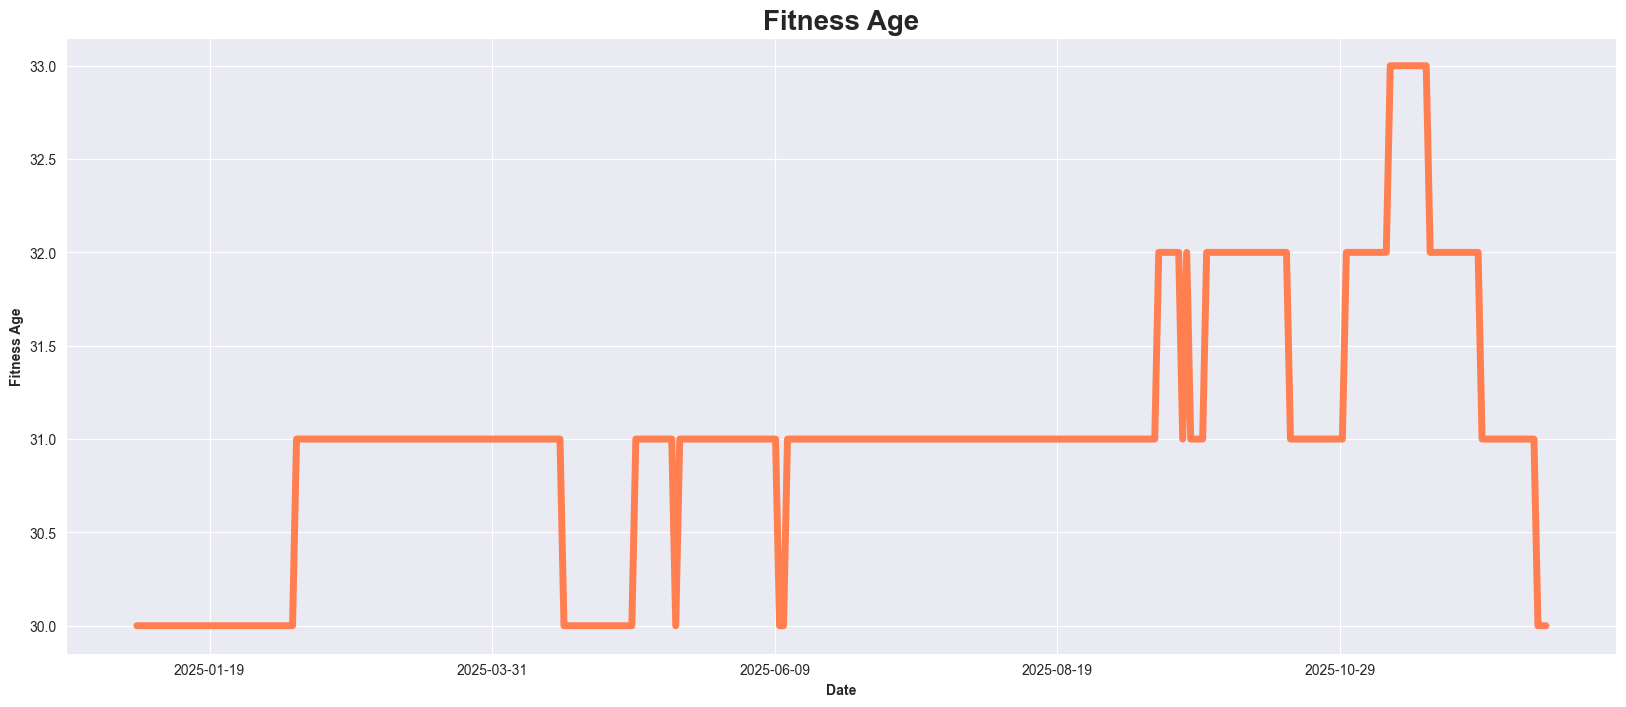

In [7]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Fitness Age'], color=MAIN_COLOR, linewidth=5)
plt.title('Fitness Age', **TITLE_KKWARGS)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Fitness Age', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.show()

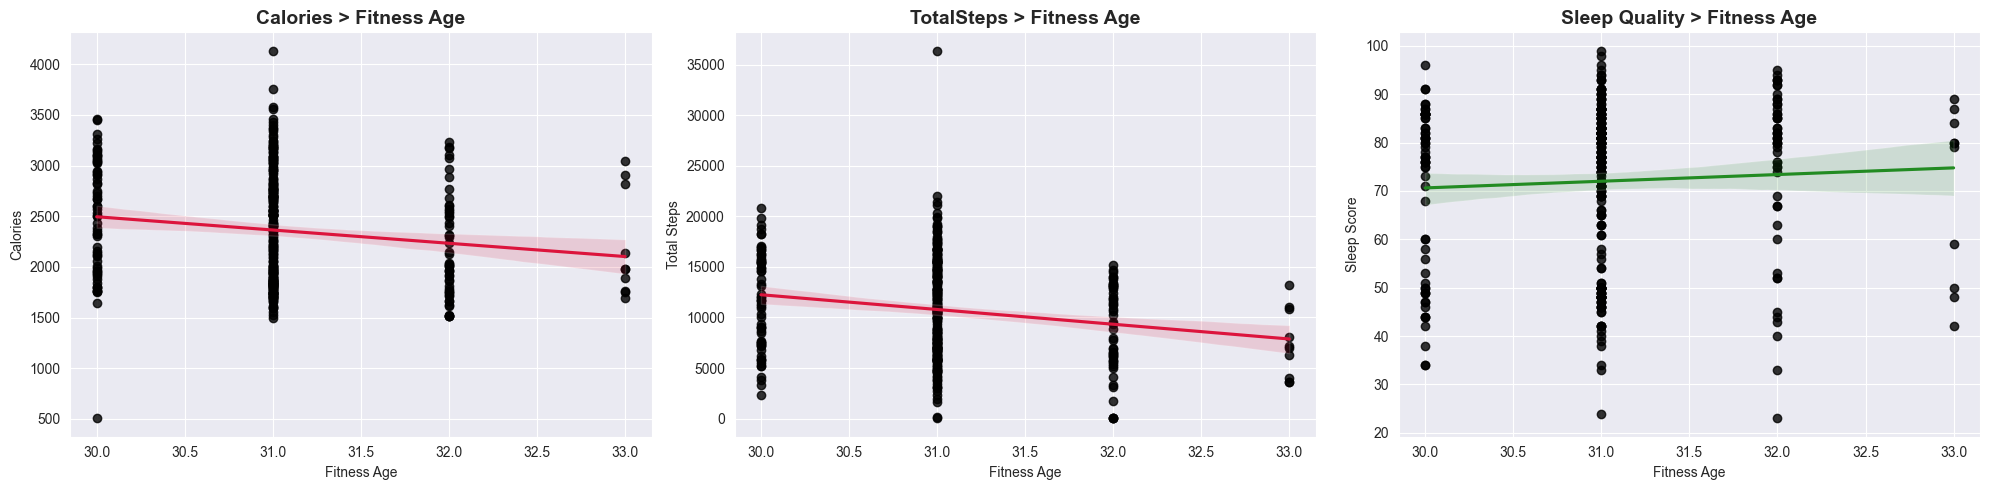

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

sns.regplot(df_viz, x='Fitness Age', y='Calories', scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax1)
ax1.set_title('Calories > Fitness Age', **SUB_TITLE_KKWARGS)

sns.regplot(df_viz, x='Fitness Age', y='Total Steps', scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax2)
ax2.set_title('TotalSteps > Fitness Age', **SUB_TITLE_KKWARGS)

sns.regplot(df_viz, x='Fitness Age', y='Sleep Score', scatter_kws={'color': 'k'}, line_kws={'color': POSITIVE_REF_COLOR}, ax=ax3 )
ax3.set_title('Sleep Quality > Fitness Age', **SUB_TITLE_KKWARGS)

plt.tight_layout()
plt.show()

# Heart Rate Data

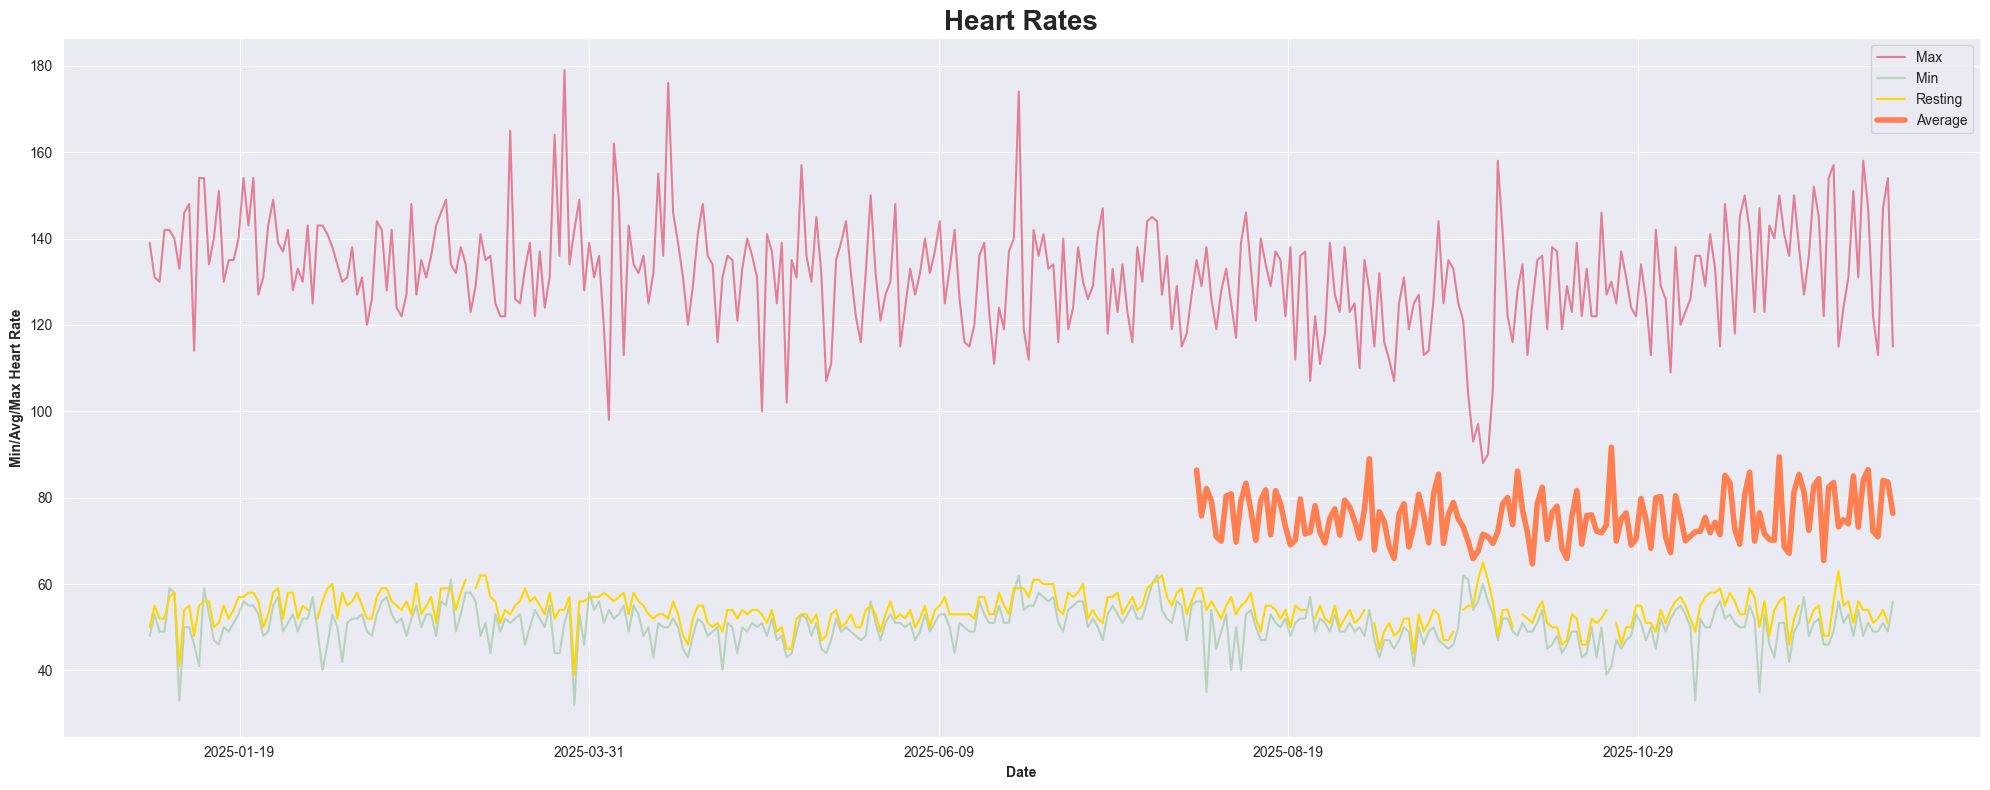

In [9]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Max Heart Rate'], color=NEGATIVE_REF_COLOR, alpha=.5)
plt.plot(df_viz['Date'], df_viz['Min Heart Rate'], color=POSITIVE_REF_COLOR, alpha=.25)
plt.plot(df_viz['Date'], df_viz['Resting Heart Rate'], color=REF_COLOR, alpha=1)
plt.plot(df_viz['Date'], df_viz['Average Heart Rate'], color=MAIN_COLOR, linewidth=4)
plt.title('Heart Rates', **TITLE_KKWARGS)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Min/Avg/Max Heart Rate', fontweight='bold')
plt.legend(['Max', 'Min ', 'Resting', 'Average'])
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.tight_layout()
plt.show()

# Total Calories Burned

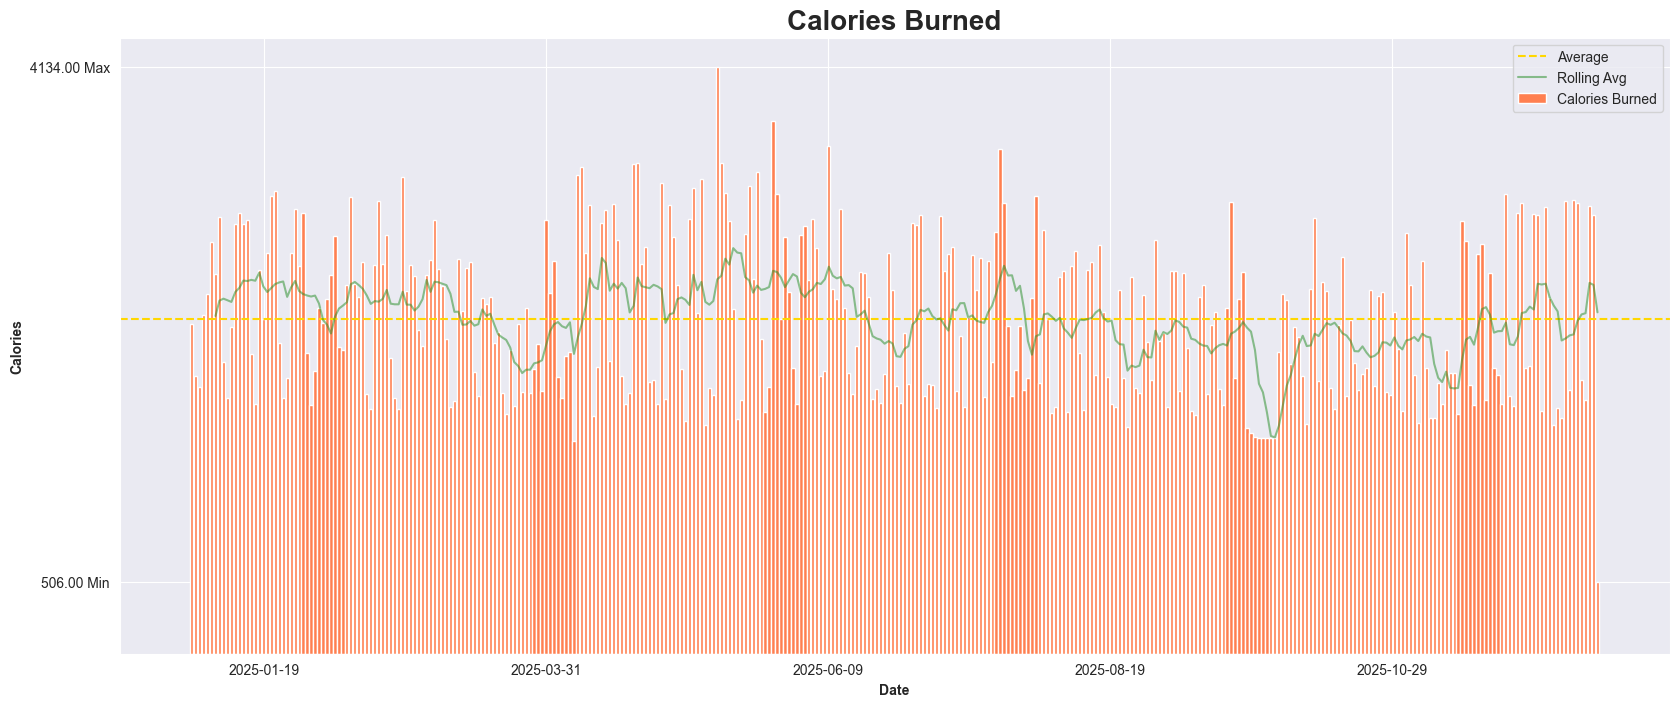

In [10]:
df_viz.loc[:, 'rolling avg'] = df_viz['Calories'].rolling(window=7).mean()
plt.figure(figsize=[20,8])
plt.bar(df_viz['Date'], df_viz['Calories'], color=MAIN_COLOR)
plt.axhline(y=df_viz['Calories'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Kilocalories {df_viz["Calories"].mean():.2f}')
plt.plot(df_viz['Date'], df_viz['rolling avg'], color=POSITIVE_REF_COLOR, alpha=0.5)
y_min = df_viz['Calories'].min()
y_max = df_viz['Calories'].max()
plt.yticks([y_min, y_max], [f'{y_min:.2f} Min', f'{y_max:.2f} Max'])
plt.title('Calories Burned', **TITLE_KKWARGS)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Calories', fontweight='bold')
plt.legend(['Average', 'Rolling Avg', 'Calories Burned'])
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.show()

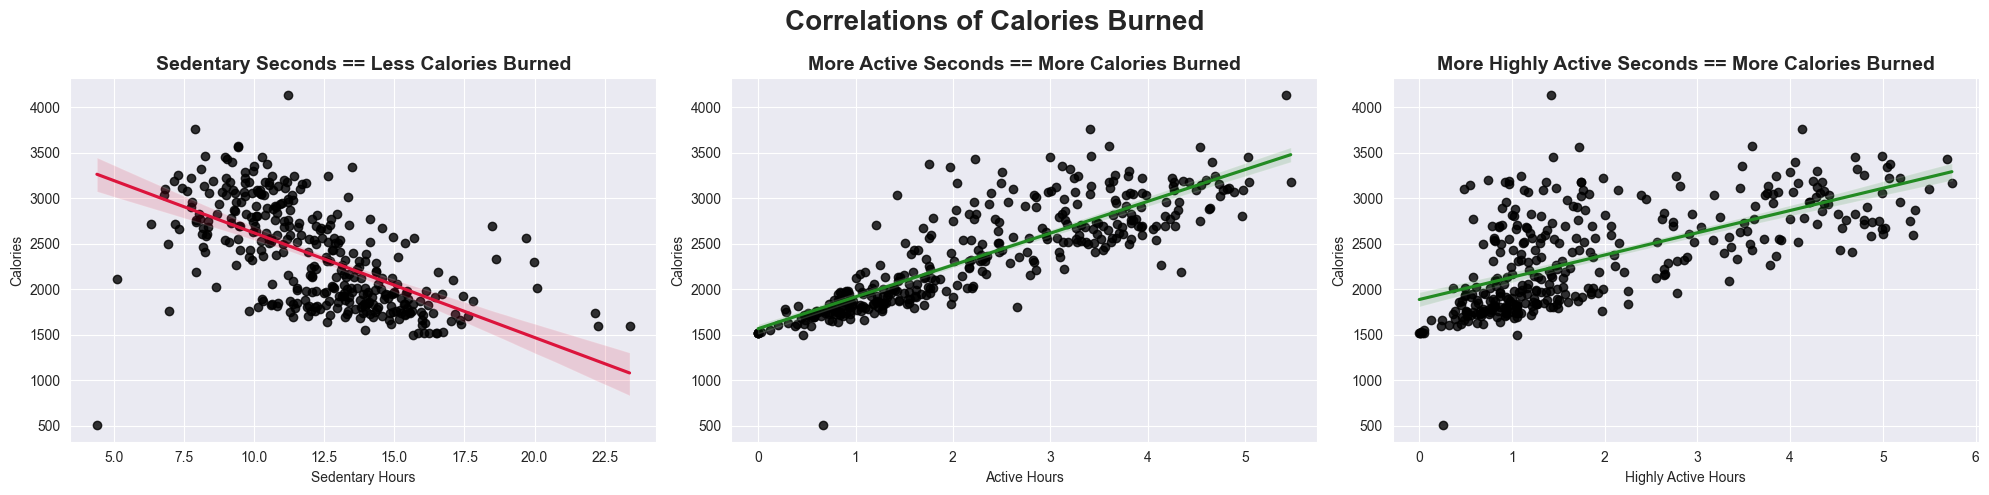

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))
fig.suptitle('Correlations of Calories Burned', fontsize=20, fontweight='bold')

sns.regplot(df_viz, x=df_viz['Sedentary Seconds'] / 3600, y='Calories', scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax1)
ax1.set_title('Sedentary Seconds == Less Calories Burned', **SUB_TITLE_KKWARGS)
ax1.set_xlabel('Sedentary Hours')

sns.regplot(df_viz, x=df_viz['Active Seconds'] / 3600, y='Calories', scatter_kws={'color': 'k'}, line_kws={'color': POSITIVE_REF_COLOR}, ax=ax2 )
ax2.set_title('More Active Seconds == More Calories Burned', **SUB_TITLE_KKWARGS)
ax2.set_xlabel('Active Hours')

sns.regplot(df_viz, x=df_viz['Highly Active Seconds'] / 3600, y='Calories', scatter_kws={'color': 'k'}, line_kws={'color': POSITIVE_REF_COLOR}, ax=ax3 )
ax3.set_title('More Highly Active Seconds == More Calories Burned', **SUB_TITLE_KKWARGS)
ax3.set_xlabel('Highly Active Hours')

plt.tight_layout()
plt.show()

# Intensity Hours
The goal is 150 minutes of Intense minutes through the week

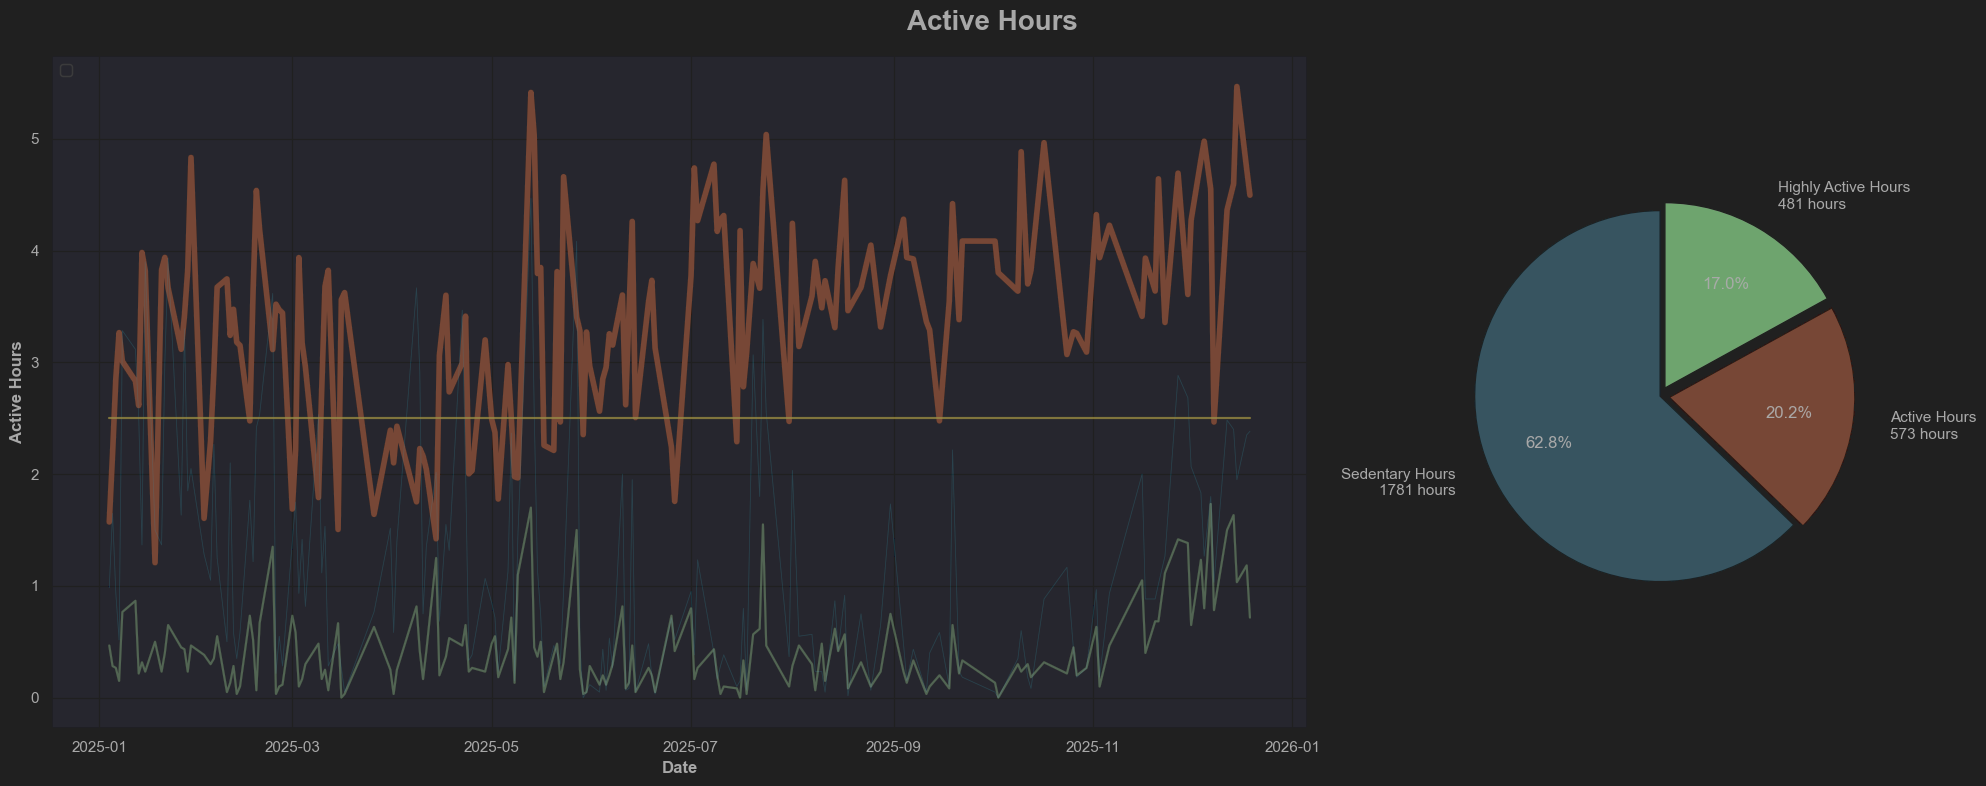
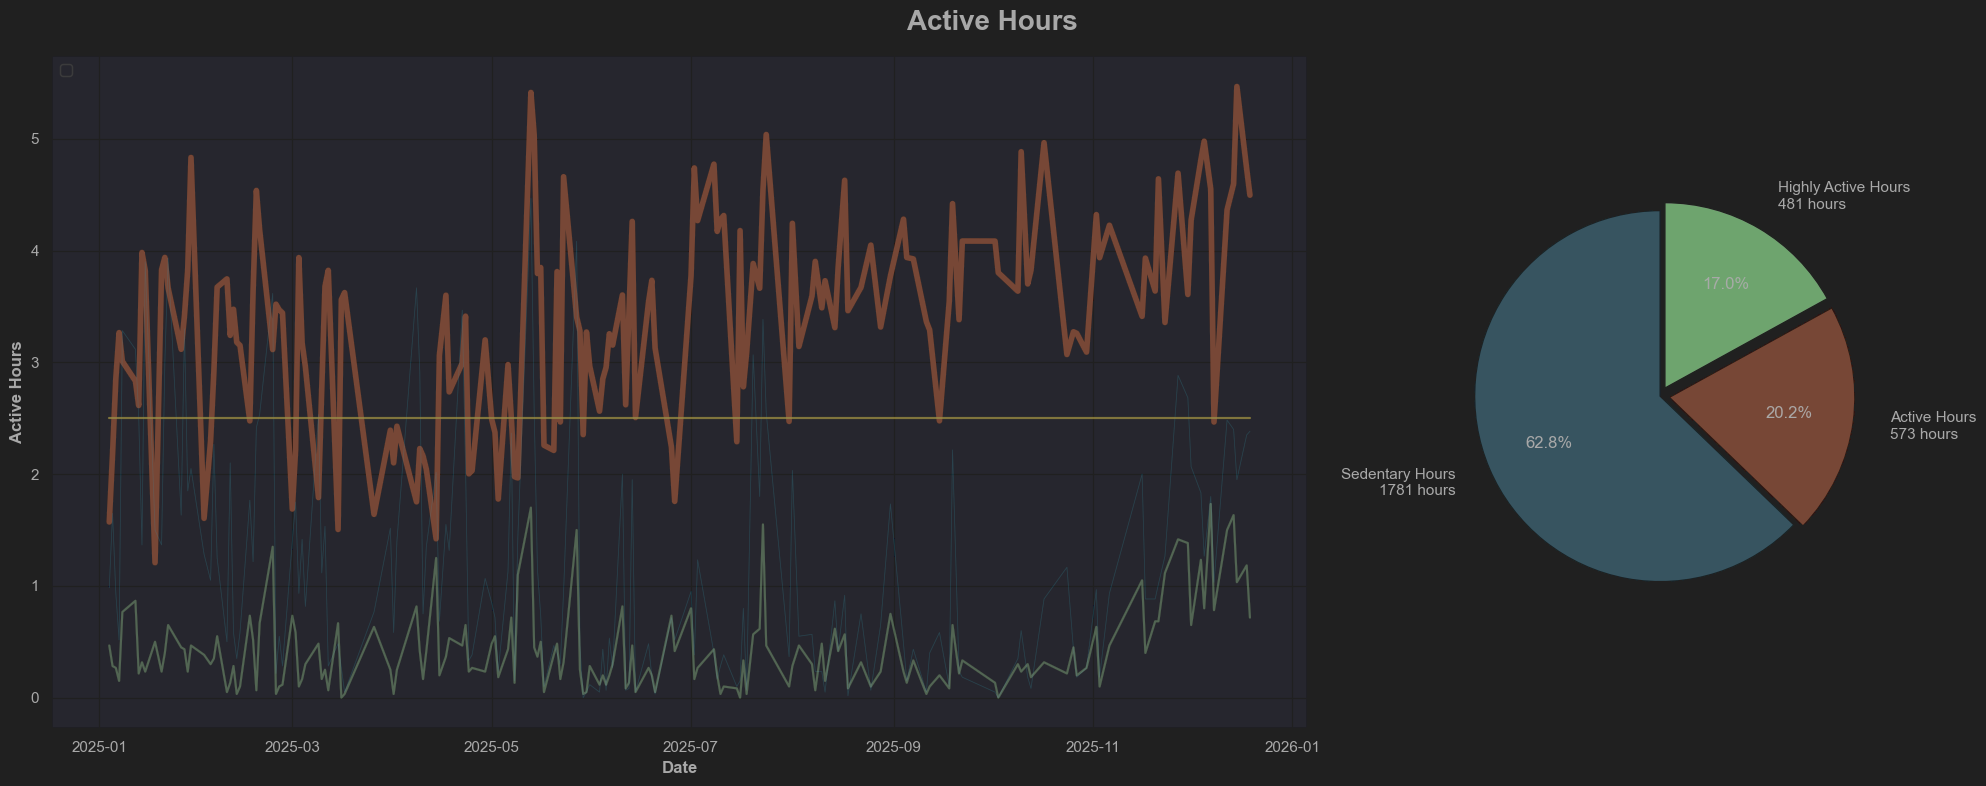

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_41072/723314096.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')


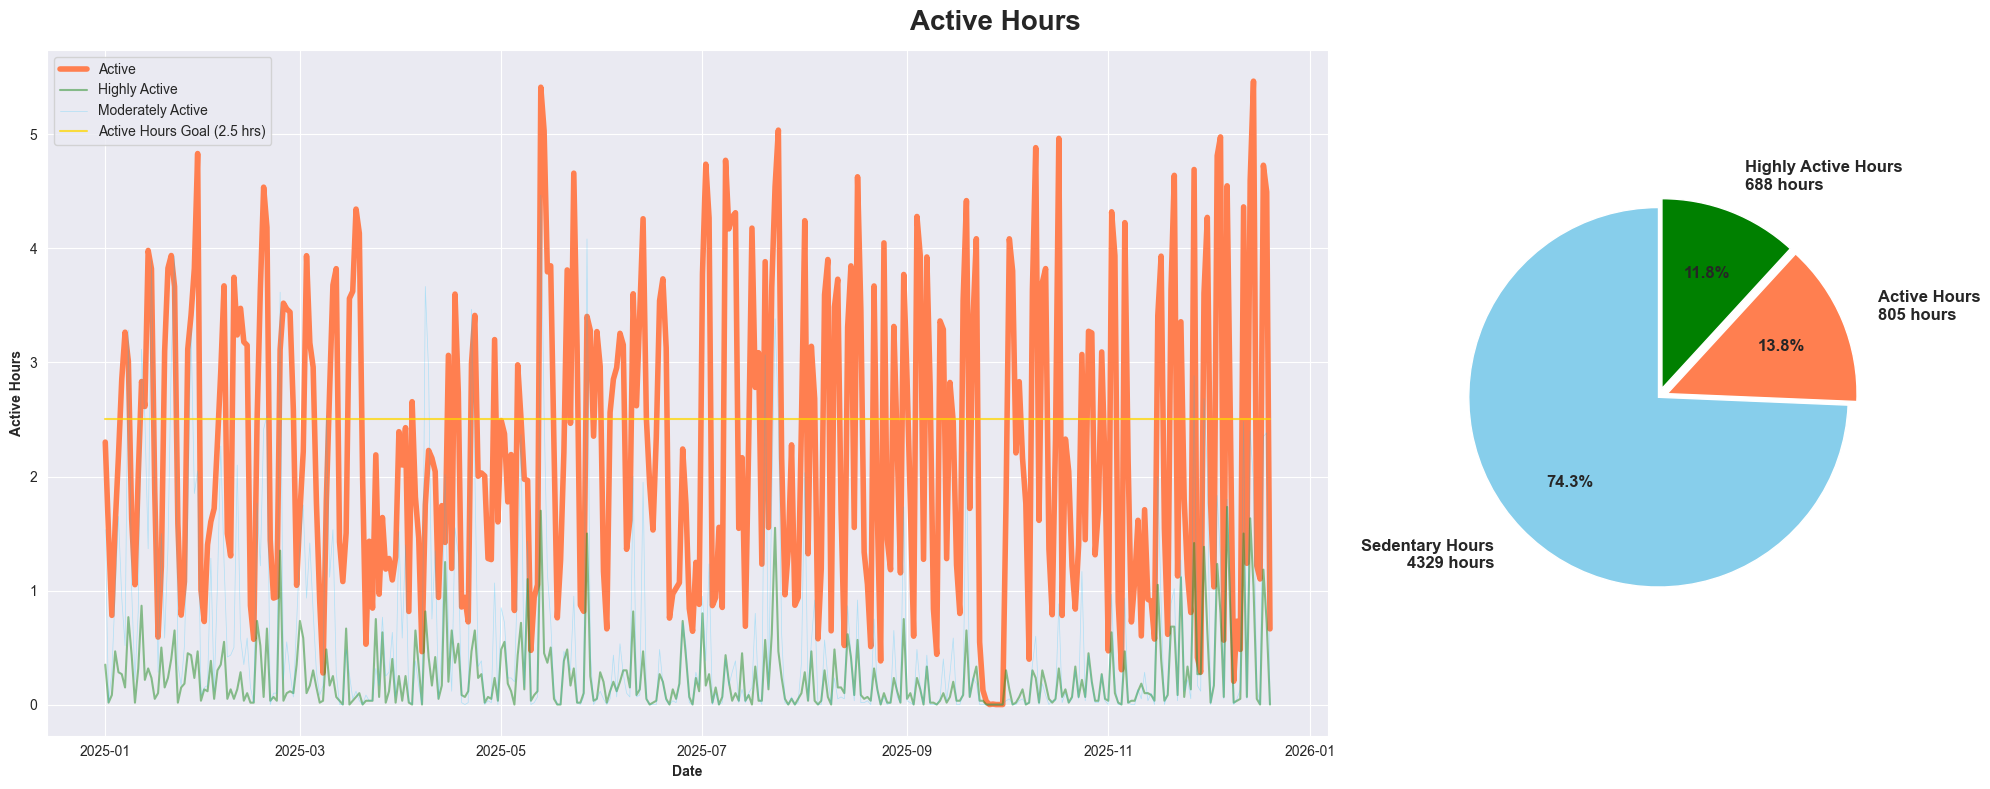

In [12]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('Active Hours', **TITLE_KKWARGS)

ax1.plot(df_viz['Date'], df_viz['Active Seconds'] / 3600, color=MAIN_COLOR, linewidth=4)
ax1.plot(df_viz['Date'], df_viz['Vigorous Intensity Minutes'] / 60, color=POSITIVE_REF_COLOR, alpha=.5)
ax1.plot(df_viz['Date'], df_viz['Moderate Intensity Minutes'] / 60, color='deepskyblue', alpha=.25, linewidth=.5)
ax1.plot(df_viz['Date'], df_viz['Intensity Minutes Goal'] / 60, color=REF_COLOR, alpha=.75)
ax1.legend(loc='upper left')
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Active Hours', fontweight='bold')
ax1.legend(['Active', 'Highly Active', 'Moderately Active', 'Active Hours Goal (2.5 hrs)'])
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))

sizes = df_viz['Sedentary Seconds'].sum(), df_viz['Active Seconds'].sum(), df_viz['Highly Active Seconds'].sum()
sedentary_hours = int(df_viz['Sedentary Seconds'].sum() / 3600)
active_hours = int(df_viz['Active Seconds'].sum() / 3600)
high_active_hours = int(df_viz['Highly Active Seconds'].sum() / 3600)
explode = (0, 0.05, 0.05)
labels = [f'Sedentary Hours\n{sedentary_hours} hours', f'Active Hours\n{active_hours} hours', f'Highly Active Hours\n{high_active_hours} hours']
ax2.pie(sizes, labels=labels, explode=explode, autopct='%1.1f%%', pctdistance=.65, labeldistance=1.2, startangle=90, colors=['skyblue', MAIN_COLOR, 'g'], textprops={'fontweight': 'bold', 'fontsize': 12})
# ax2.font
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Total Steps Taken
That spike is from a hike in the Columbia River Gorge

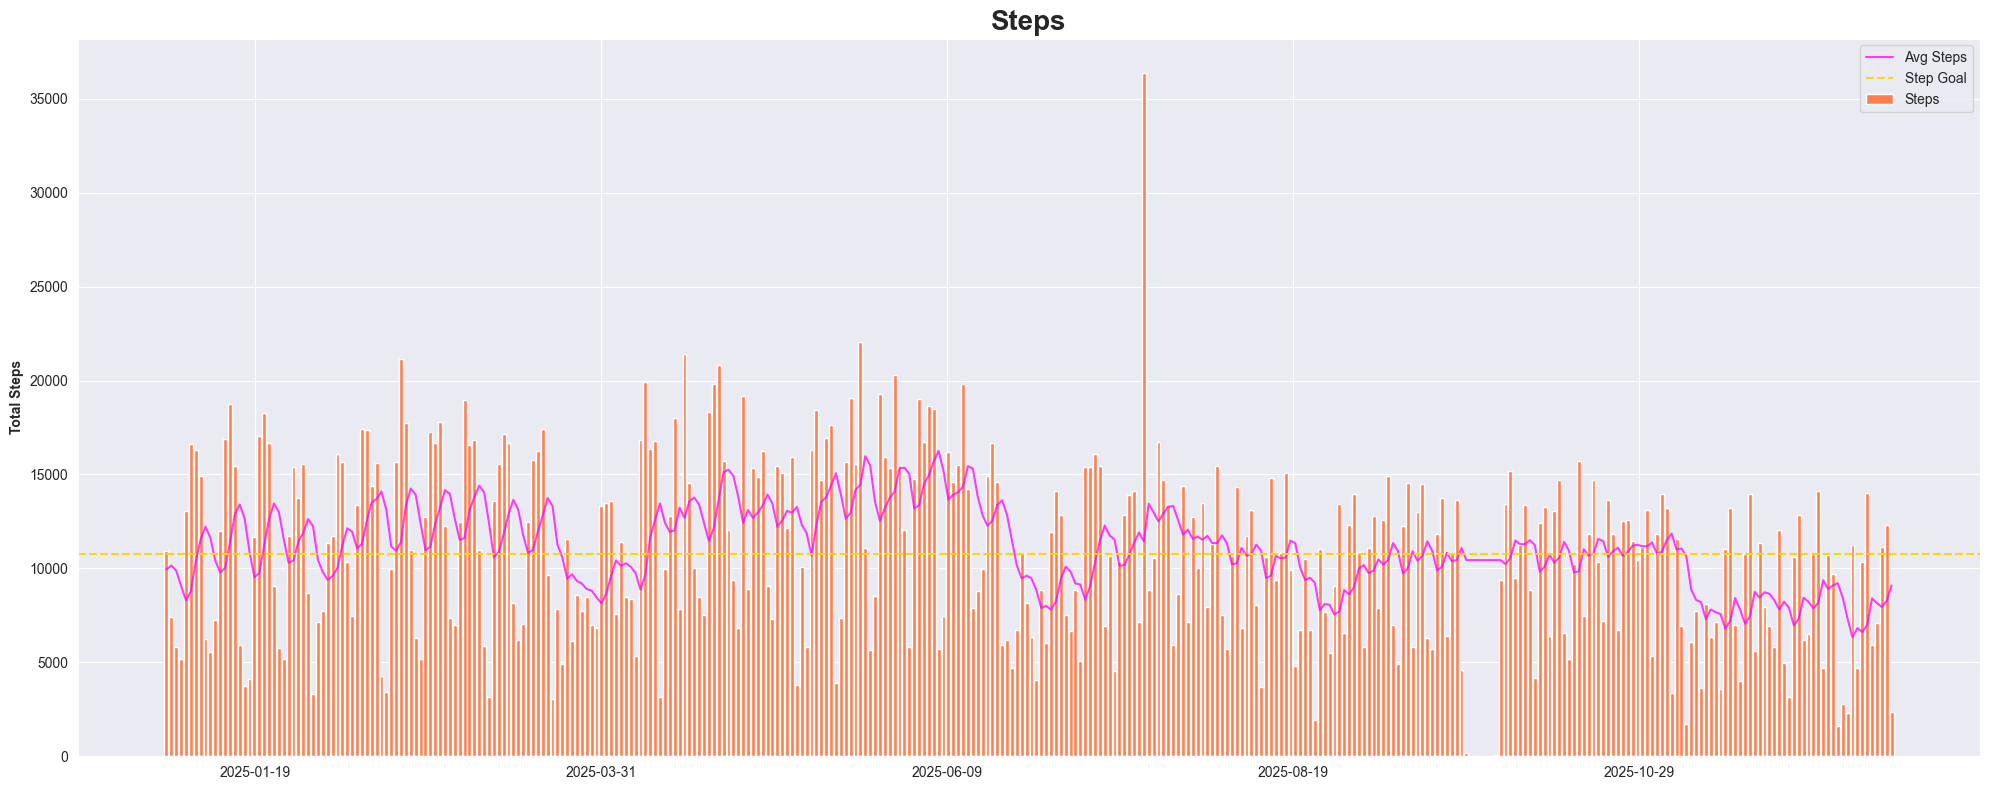

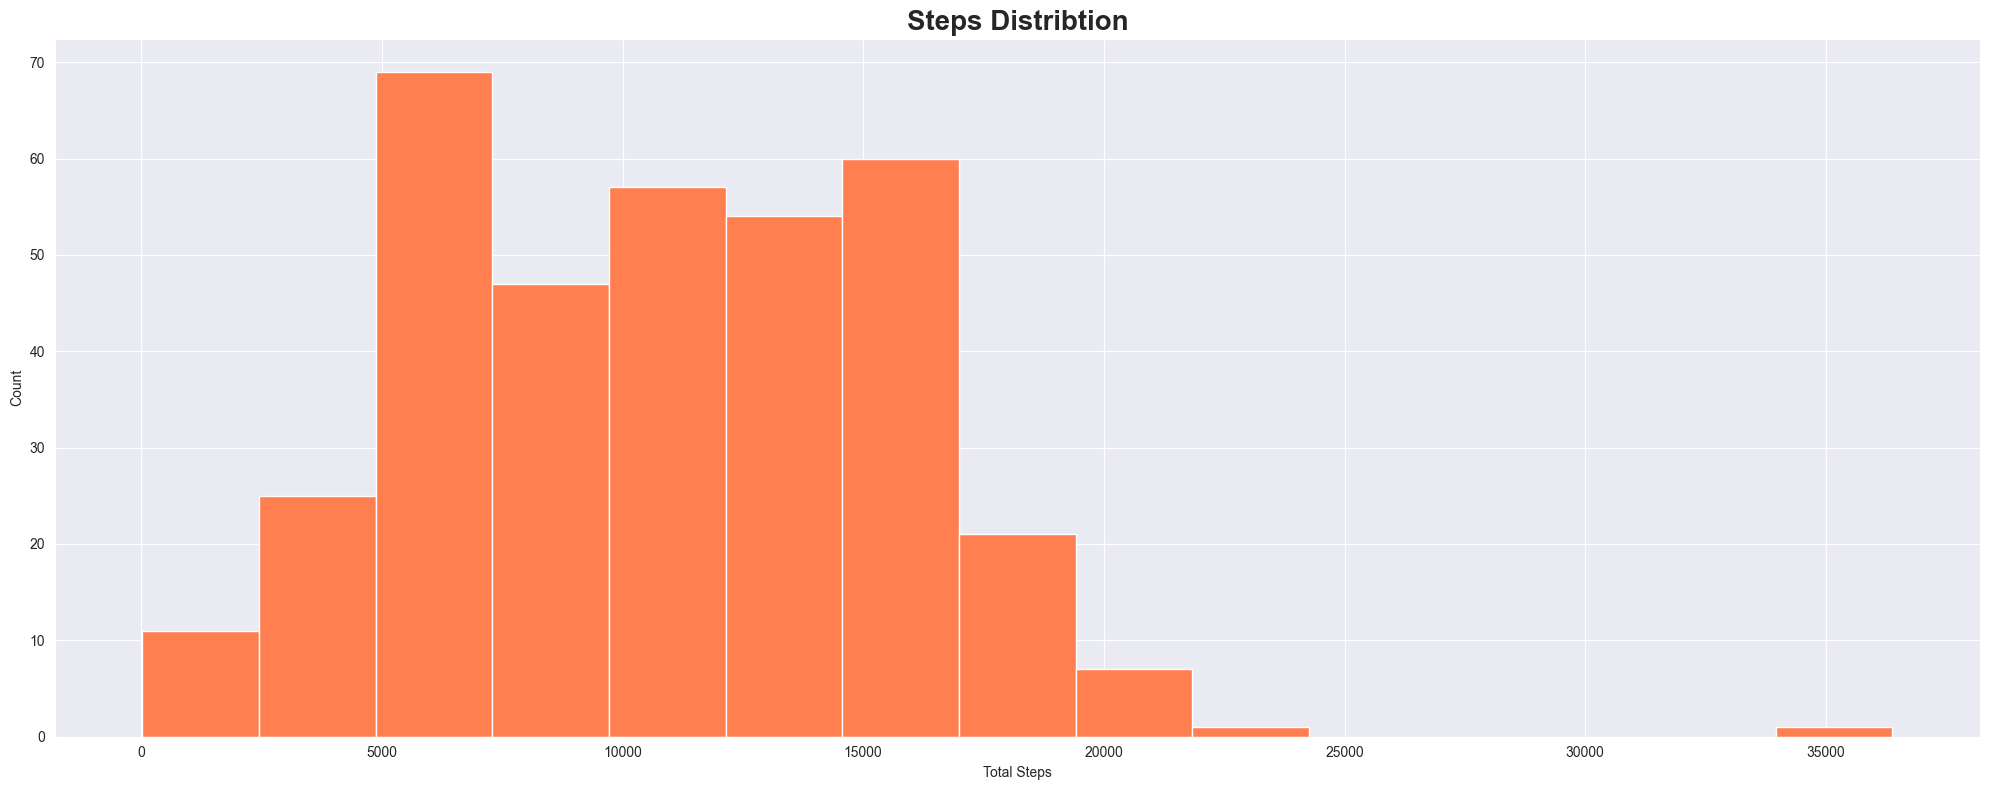

In [13]:
plt.figure(figsize=[20,8])
plt.bar(df_viz['Date'], df_viz['Total Steps'], color=MAIN_COLOR)
plt.plot(df_viz['Date'], df_viz['Daily Step Goal'], color='magenta', alpha=.75)
plt.axhline(y=df_viz['Total Steps'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Total Steps"].mean():.2f}')
y_min = df_viz['Total Steps'].min()
y_max = df_viz['Total Steps'].max()
plt.ylabel('Total Steps', fontweight='bold')
plt.title('Steps', **TITLE_KKWARGS)
plt.legend(['Avg Steps', 'Step Goal', 'Steps'])
ax1 = plt.gca()
ax1.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.tight_layout()
plt.show()

plt.figure(figsize=[20,8])
plt.hist(df_viz['Total Steps'], bins=15, color=MAIN_COLOR)
plt.title('Steps Distribtion', **TITLE_KKWARGS)
plt.xlabel('Total Steps')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Total Miles Walked


In [14]:
df_viz_tmp = df_viz[['Date', 'Total Distance Meters']]
df_viz_tmp.loc[:, 'Total Distance Meters'] = df_viz_tmp['Total Distance Meters'] / 1609

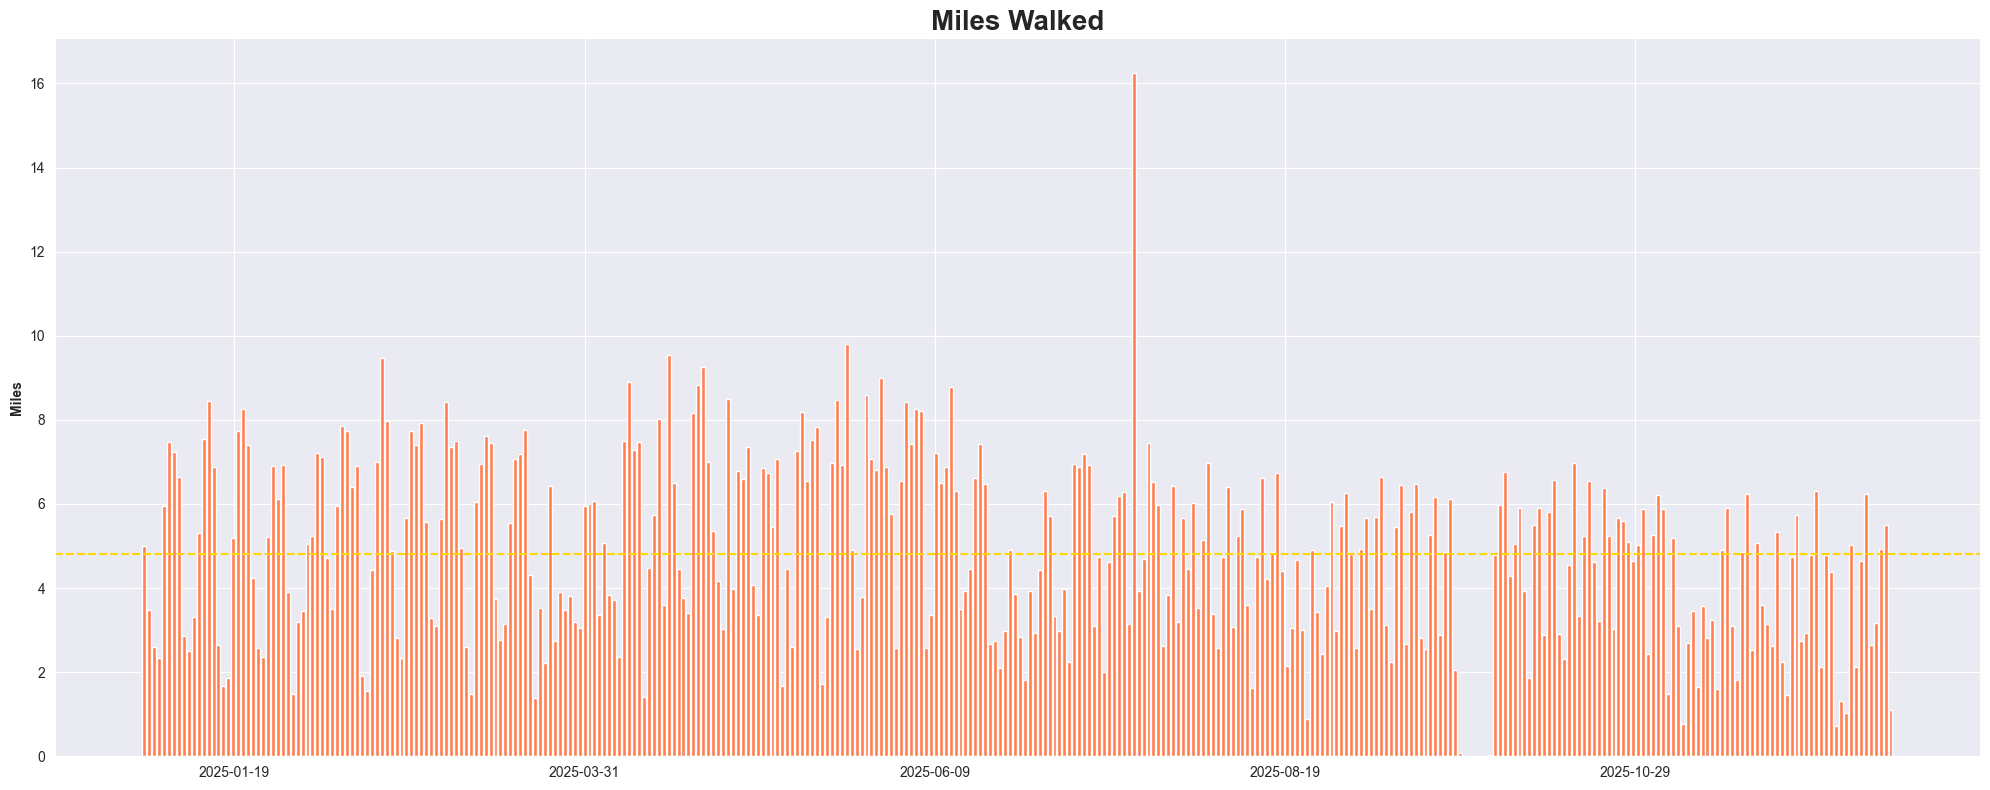

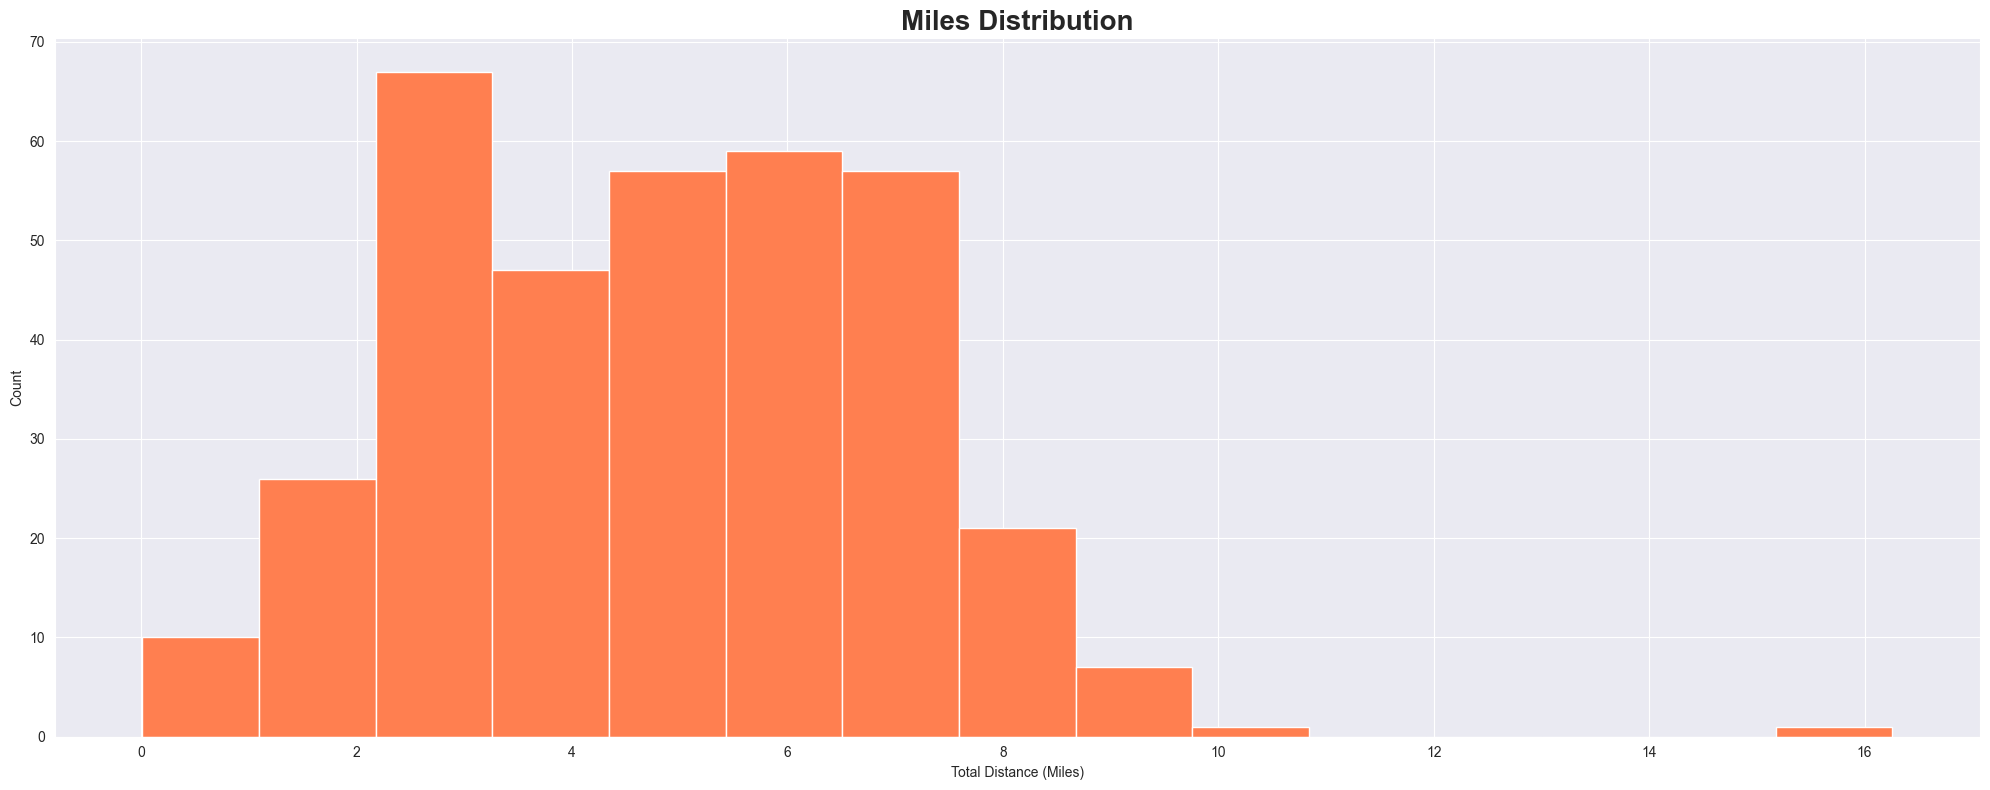

In [15]:
plt.figure(figsize=[20,8])
plt.bar(df_viz_tmp['Date'], df_viz_tmp['Total Distance Meters'], color=MAIN_COLOR)
plt.axhline(y=df_viz_tmp['Total Distance Meters'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz_tmp["Total Distance Meters"].mean():.2f}')
y_min = df_viz_tmp['Total Distance Meters'].min()
y_max = df_viz_tmp['Total Distance Meters'].max()
plt.title('Miles Walked', **TITLE_KKWARGS)
plt.ylabel('Miles', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.tight_layout()
plt.show()

plt.figure(figsize=[20,8])
plt.hist(df_viz_tmp['Total Distance Meters'], bins=15, color=MAIN_COLOR)
plt.title('Miles Distribution', **TITLE_KKWARGS)
plt.xlabel('Total Distance (Miles)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Sleep Duration

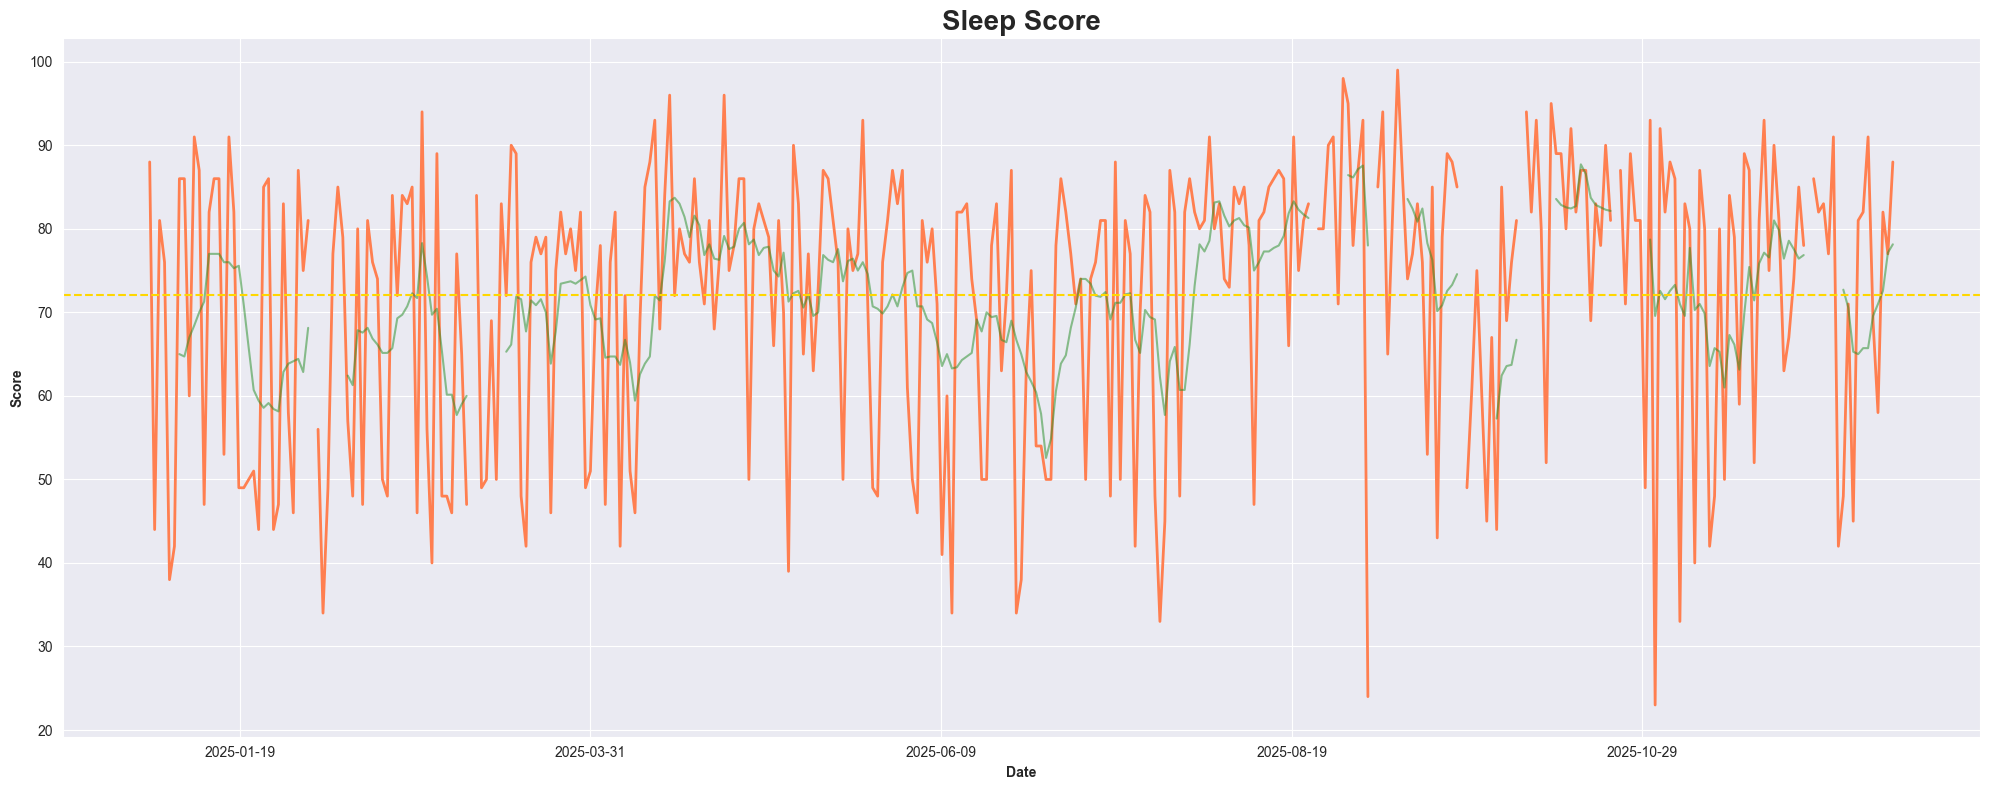

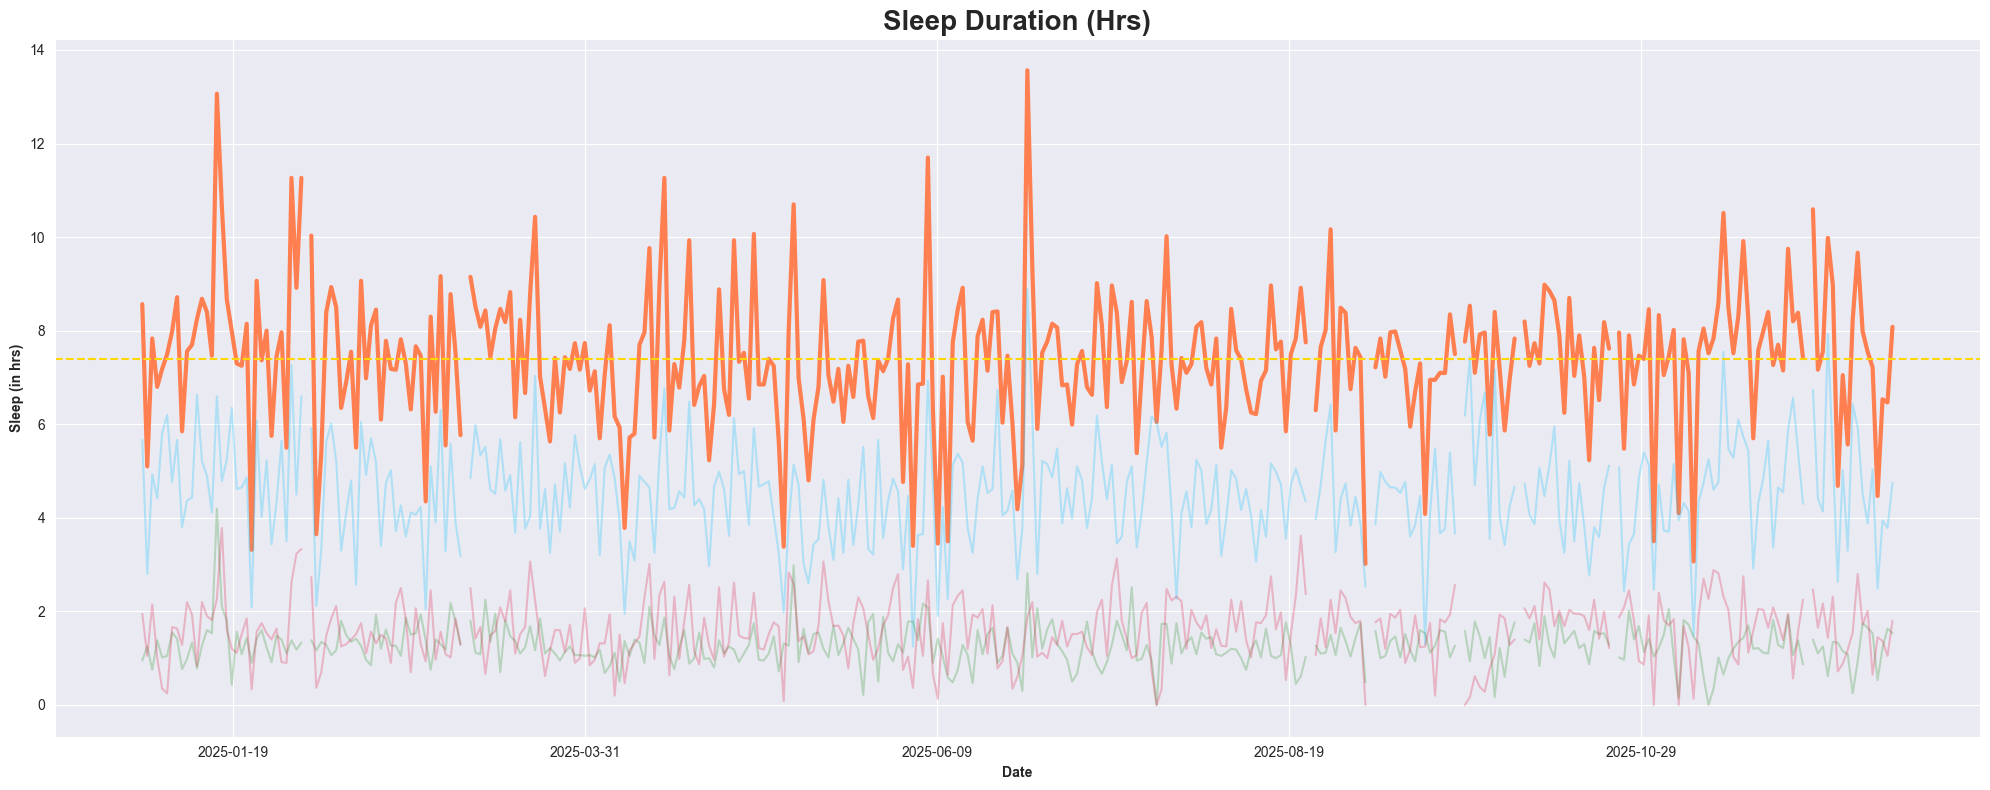

In [16]:
df_viz.loc[:, 'rolling avg'] = df_viz['Sleep Score'].rolling(window=7).mean()
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Sleep Score'], color=MAIN_COLOR, linewidth=2)
plt.plot(df_viz['Date'], df_viz['rolling avg'], color=POSITIVE_REF_COLOR, alpha=.5)
plt.axhline(y=df_viz['Sleep Score'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Sleep Score"].mean():.2f}')
plt.title('Sleep Score', **TITLE_KKWARGS)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.tight_layout()
plt.show()

plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Sleep Time Seconds'] / 3600, color=MAIN_COLOR, linewidth=3)
plt.plot(df_viz['Date'], df_viz['Light Sleep Seconds'] / 3600, color='deepskyblue', alpha=.25)
plt.plot(df_viz['Date'], df_viz['Deep Sleep Seconds'] / 3600, color='forestgreen', alpha=.25)
plt.plot(df_viz['Date'], df_viz['Rem Sleep Seconds'] / 3600, color='crimson', alpha=.25)
plt.axhline(y=df_viz['Sleep Time Seconds'].mean() / 3600, linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Sleep Time Seconds"].mean() / 3600:.2f}')
plt.title('Sleep Duration (Hrs)', **TITLE_KKWARGS)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Sleep (in hrs)', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.tight_layout()
plt.show()

# Sleep Score

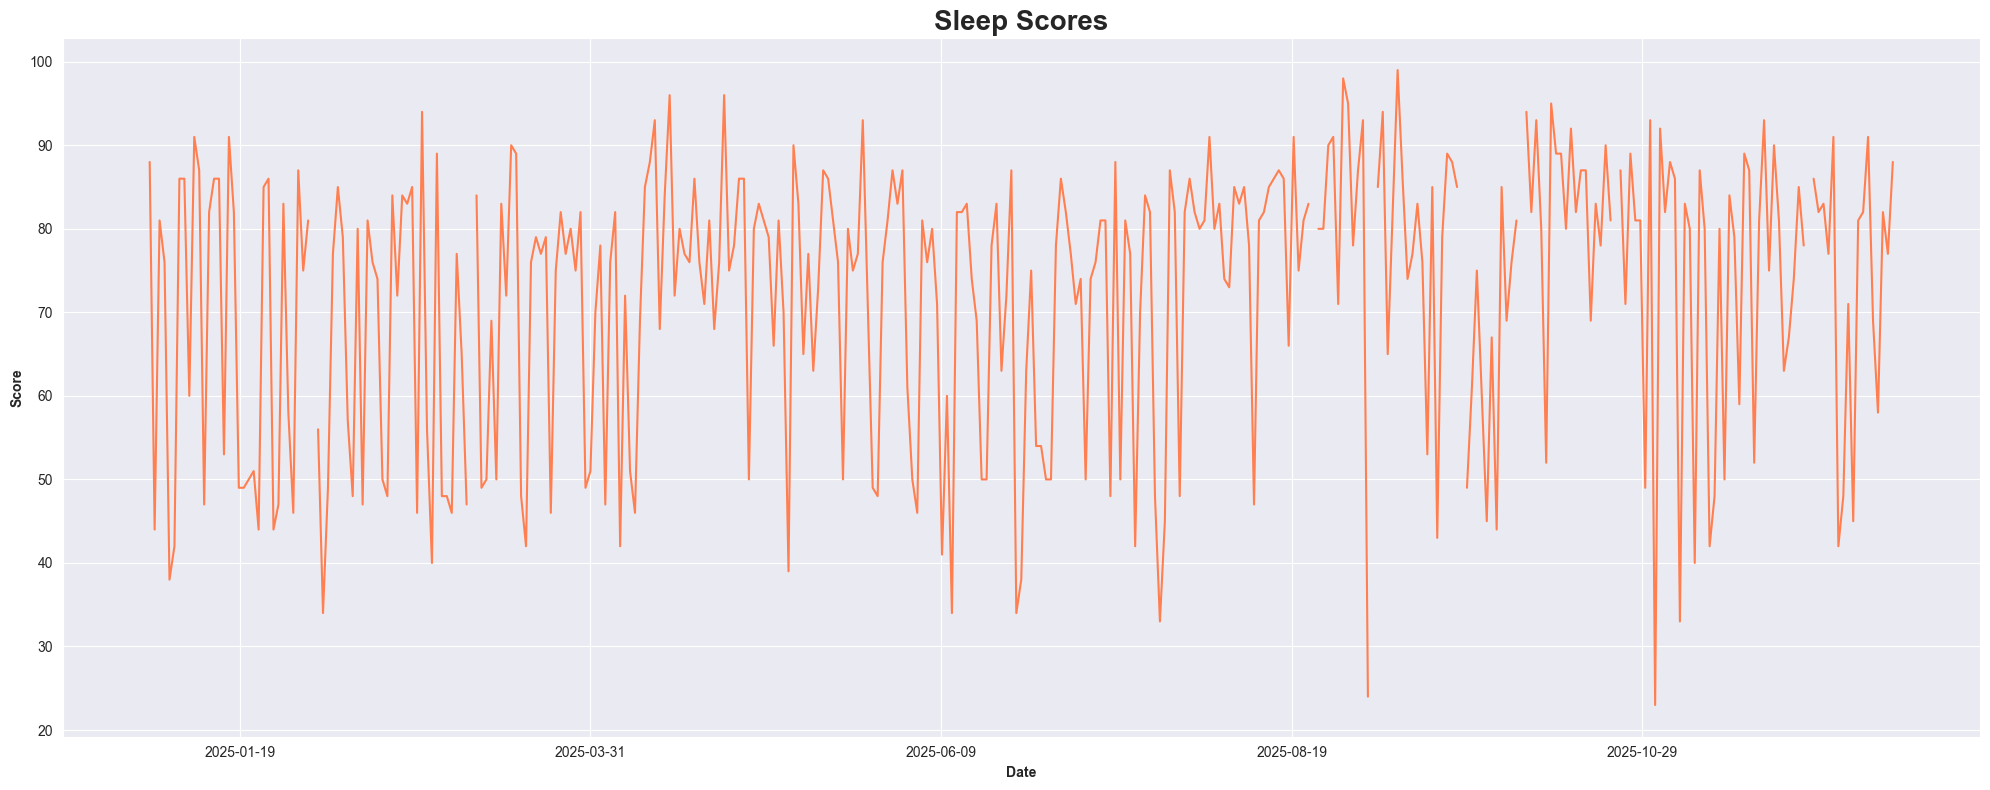

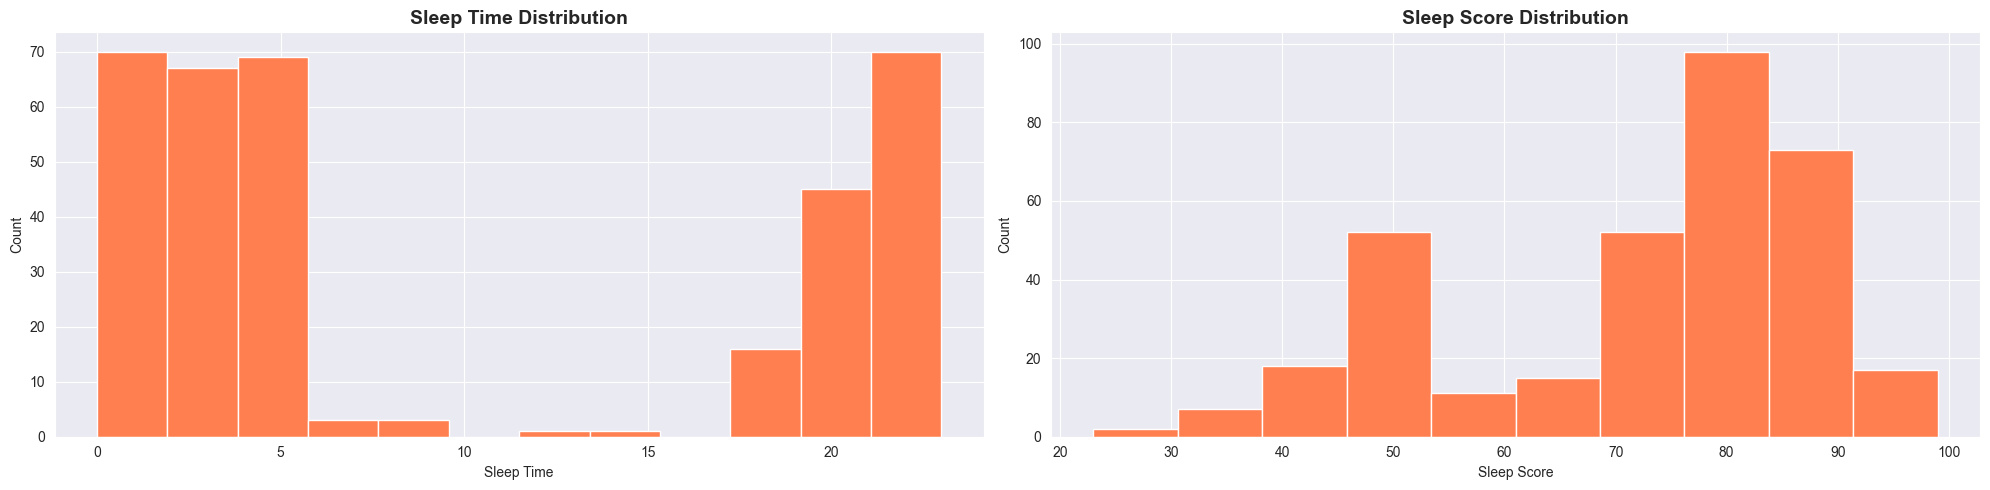

In [17]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Sleep Score'], color=MAIN_COLOR)
plt.title('Sleep Scores', **TITLE_KKWARGS)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

ax1.hist(df_viz['Sleep Start Timestamp Local'].dt.hour, bins=12, color=MAIN_COLOR)
ax1.set_title('Sleep Time Distribution', **SUB_TITLE_KKWARGS)
ax1.set_xlabel('Sleep Time')
ax1.set_ylabel('Count')

## What my aggregated sleep scores are
ax2.hist(df_viz['Sleep Score'], bins=10, color=MAIN_COLOR)
ax2.set_title('Sleep Score Distribution', **SUB_TITLE_KKWARGS)
ax2.set_xlabel('Sleep Score')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Sleep Quality

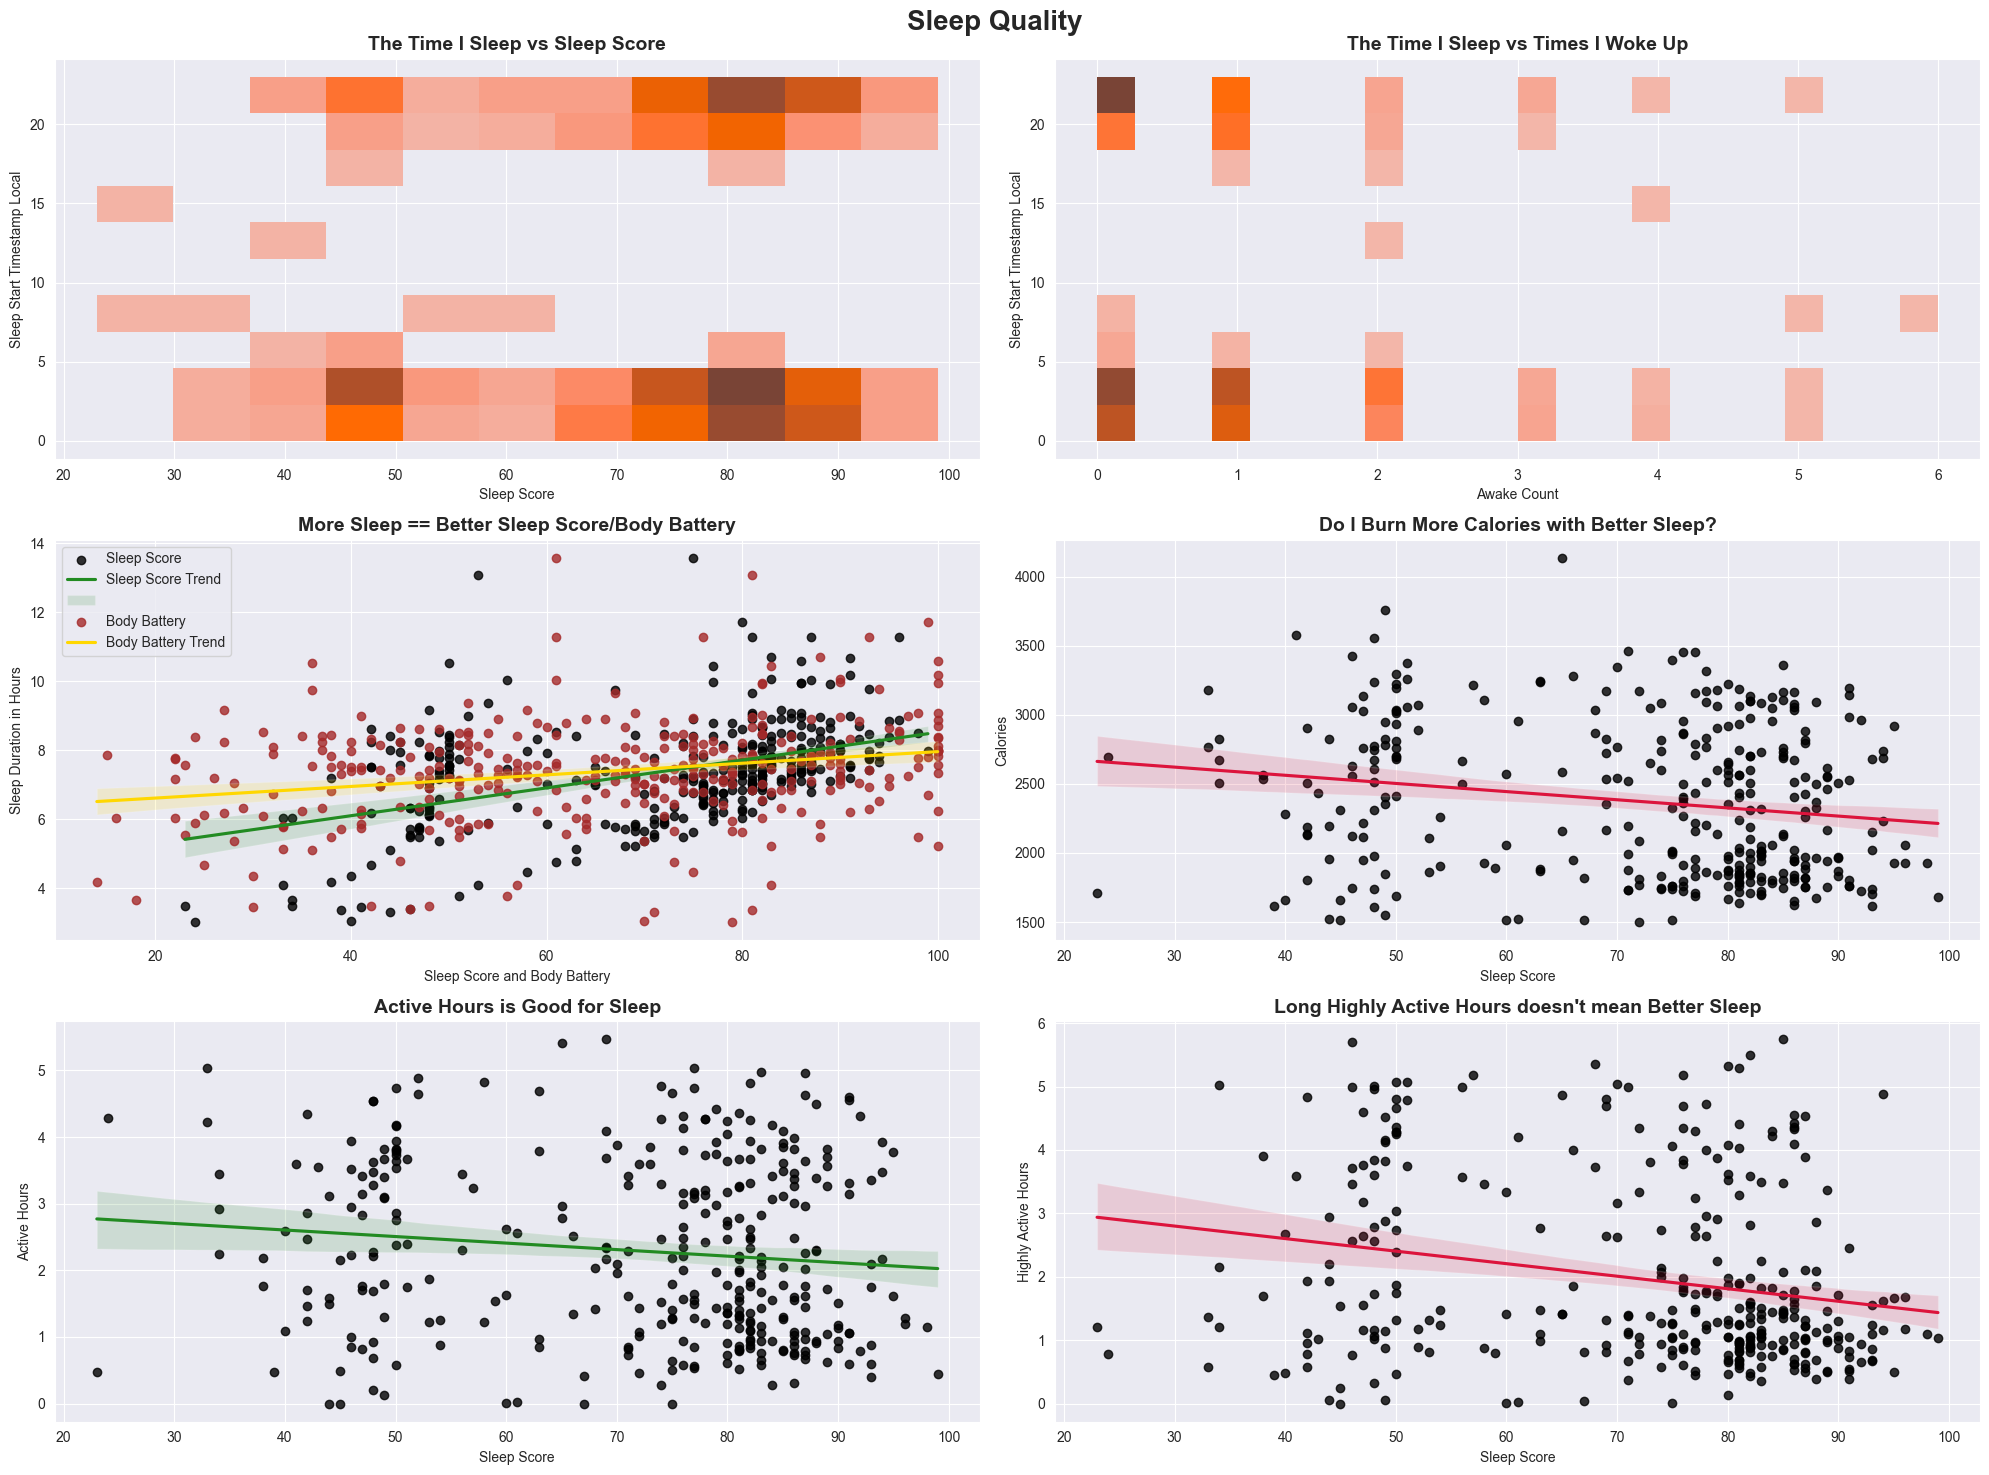

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


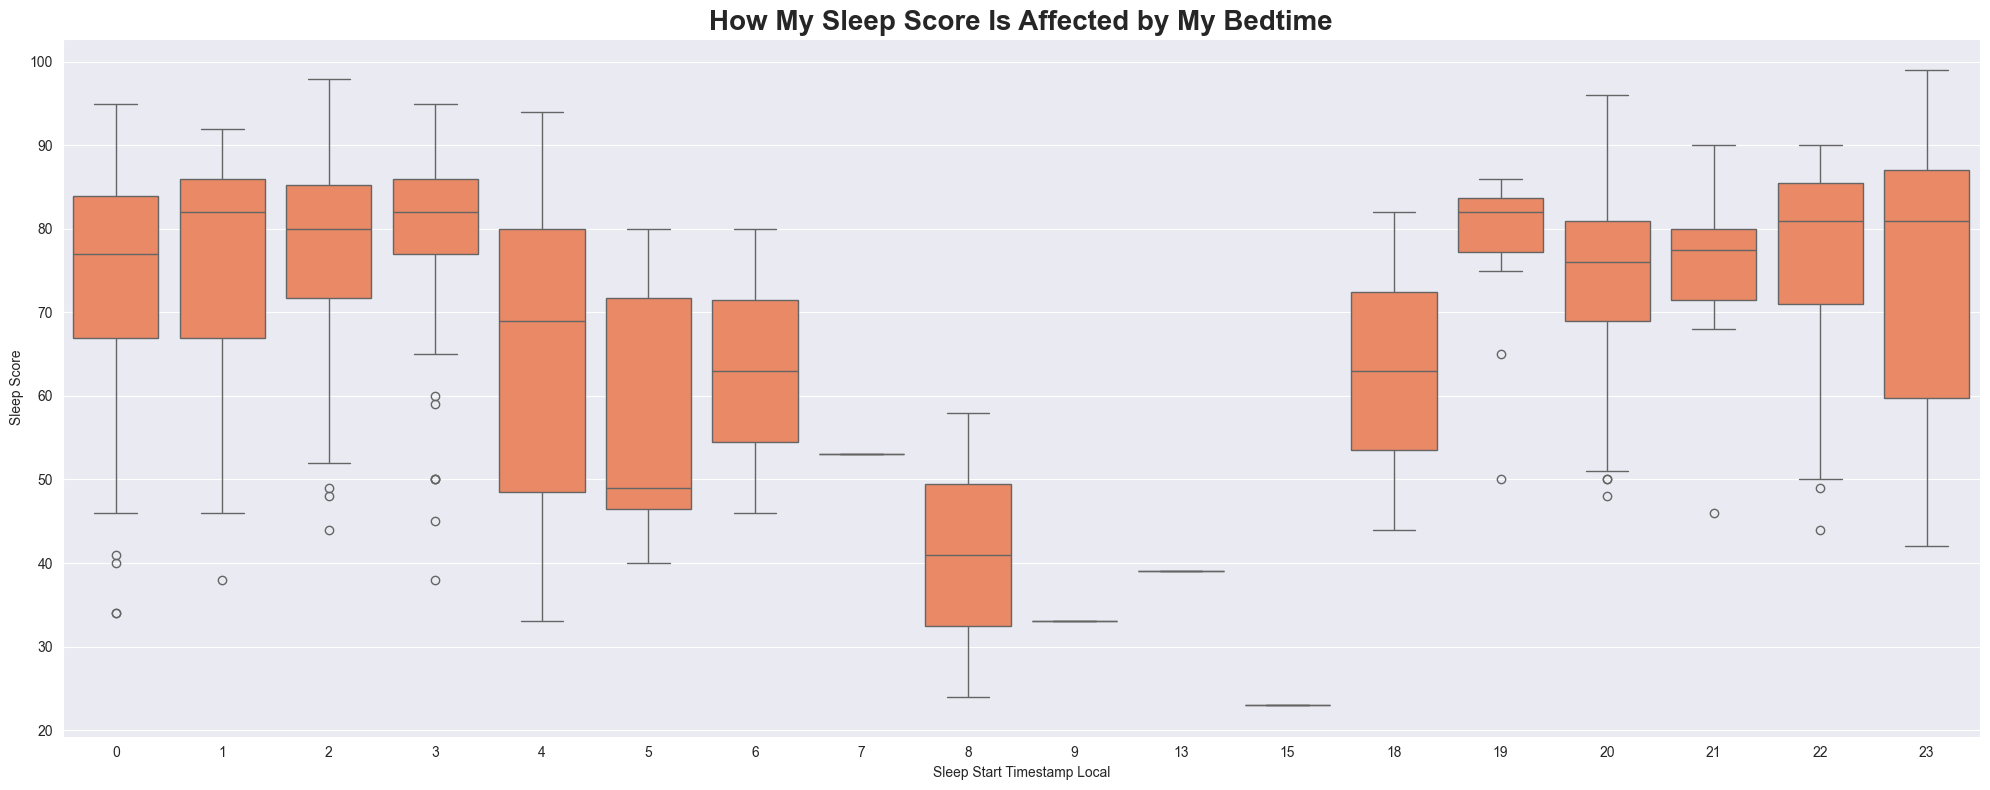

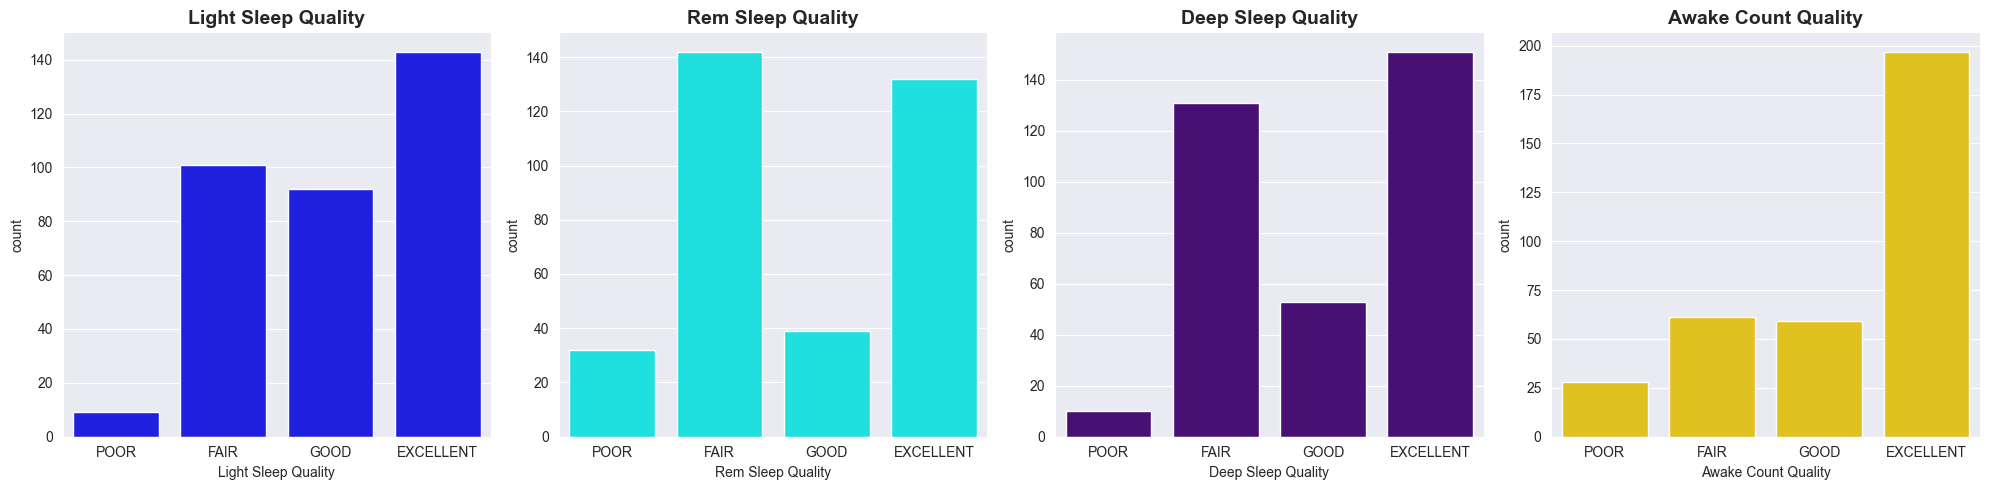

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_41072/1231693137.py:68: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.stripplot(df_viz, x='Sleep Quality', y='Average Stress Level', color=MAIN_COLOR, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax2)
/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_41072/1231693137.py:77: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.swarmplot(df_viz, x='Sleep Quality', y=df_viz['Stress Seconds'] / 3600, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, color=MAIN_COLOR, order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax4)


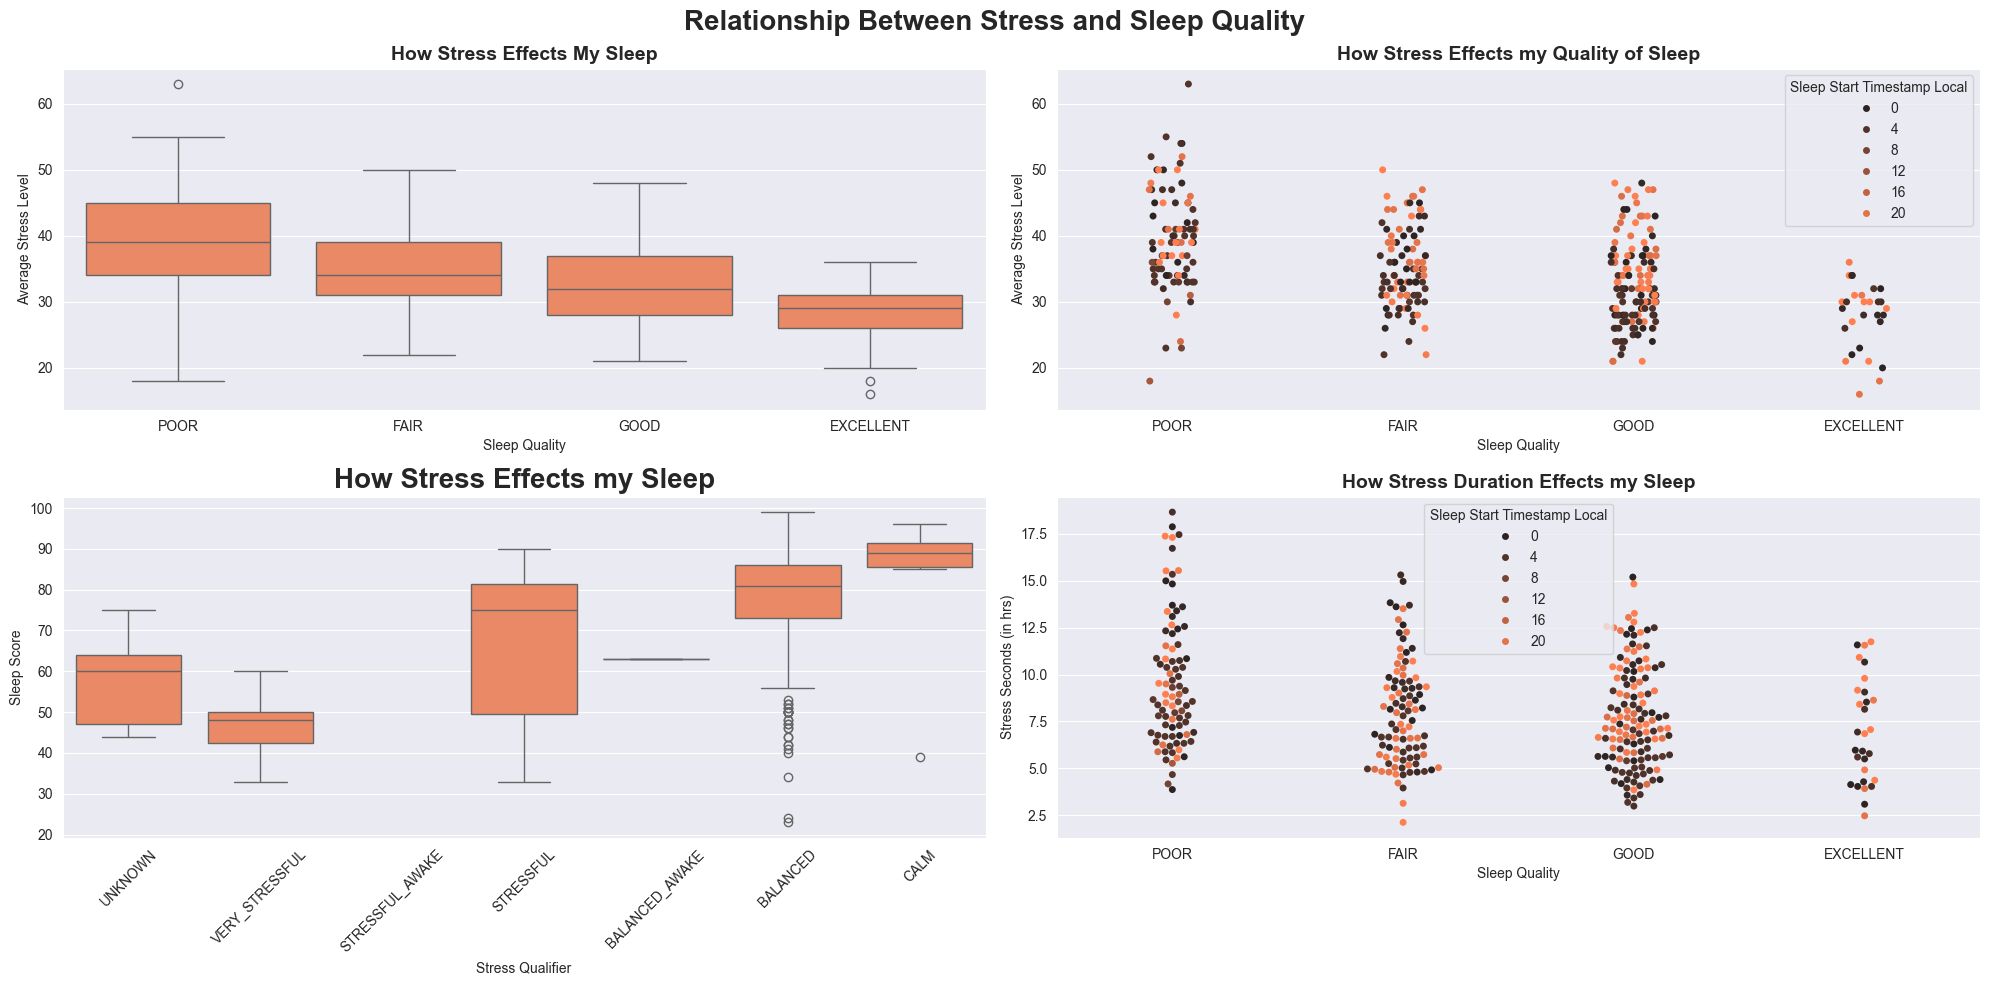

In [18]:
# Sleep Quality
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(nrows=3, ncols=2, figsize=(20, 15))
fig.suptitle('Sleep Quality', **TITLE_KKWARGS)

sns.histplot(df_viz, x='Sleep Score', y=df_viz['Sleep Start Timestamp Local'].dt.hour, ax=ax1, color=MAIN_COLOR, )
ax1.set_title('The Time I Sleep vs Sleep Score', **SUB_TITLE_KKWARGS)

sns.histplot(df_viz, y=df_viz['Sleep Start Timestamp Local'].dt.hour, x=df_viz['Awake Count'], ax=ax2, color=MAIN_COLOR, )
ax2.set_title('The Time I Sleep vs Times I Woke Up', **SUB_TITLE_KKWARGS)

sns.regplot(df_viz, x='Sleep Score', y=df_viz['Sleep Time Seconds'] / 3600, scatter_kws={'color': 'k'}, line_kws={'color': POSITIVE_REF_COLOR}, ax=ax3)
sns.regplot(df_viz, x='Body Battery', y=df_viz['Sleep Time Seconds'] / 3600, scatter_kws={'color': 'brown'}, line_kws={'color': REF_COLOR}, ax=ax3)
ax3.set_title('More Sleep == Better Sleep Score/Body Battery', **SUB_TITLE_KKWARGS)
ax3.legend(['Sleep Score', 'Sleep Score Trend', '', 'Body Battery', 'Body Battery Trend'])
ax3.set_xlabel('Sleep Score and Body Battery')
ax3.set_ylabel('Sleep Duration in Hours')

sns.regplot(df_viz, x='Sleep Score', y='Calories', scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax4)
ax4.set_title('Do I Burn More Calories with Better Sleep?', **SUB_TITLE_KKWARGS)

sns.regplot(df_viz, x='Sleep Score', y=df_viz['Active Seconds'] / 3600, scatter_kws={'color': 'k'}, line_kws={'color': POSITIVE_REF_COLOR}, ax=ax5)
ax5.set_title('Active Hours is Good for Sleep', **SUB_TITLE_KKWARGS)
ax5.set_ylabel('Active Hours')
sns.regplot(df_viz, x='Sleep Score', y=df_viz['Highly Active Seconds'] / 3600, scatter_kws={'color': 'k'}, line_kws={'color': NEGATIVE_REF_COLOR}, ax=ax6)
ax6.set_title('Long Highly Active Hours doesn\'t mean Better Sleep', **SUB_TITLE_KKWARGS)
ax6.set_ylabel('Highly Active Hours')

plt.tight_layout()
plt.show()

plt.figure(figsize=[20,8])
sns.boxplot(data=df_viz, y='Sleep Score', x=df_viz['Sleep Start Timestamp Local'].dt.hour.astype('Int64'), color=MAIN_COLOR, )
plt.title('How My Sleep Score Is Affected by My Bedtime', **TITLE_KKWARGS)
plt.tight_layout()
plt.show()

# Sleep Quality
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
sns.countplot(df_viz, x='Light Sleep Quality', color='blue', order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax1)
ax1.set_title('Light Sleep Quality', **SUB_TITLE_KKWARGS)

sns.countplot(df_viz, x='Rem Sleep Quality', color='aqua', order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax2)
ax2.set_title('Rem Sleep Quality', **SUB_TITLE_KKWARGS)


sns.countplot(df_viz, x='Deep Sleep Quality', color='indigo', order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax3)
ax3.set_title('Deep Sleep Quality', **SUB_TITLE_KKWARGS)


sns.countplot(df_viz, x='Awake Count Quality', color=REF_COLOR, order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax4)
ax4.set_title('Awake Count Quality', **SUB_TITLE_KKWARGS)

plt.tight_layout()
plt.show()

# sns.regplot(df_viz, x='Sleep Score', y='Highly Active Seconds', scatter_kws={'color': 'k'}, line_kws={'color': REF_COLOR}, ax=ax4)


# Stress and Sleep Quality
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.suptitle('Relationship Between Stress and Sleep Quality', **TITLE_KKWARGS)

sns.boxplot(df_viz, x='Sleep Quality', y='Average Stress Level', color=MAIN_COLOR, order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax1)
ax1.set_ylabel('Average Stress Level')
ax1.set_xlabel('Sleep Quality')
ax1.set_title('How Stress Effects My Sleep', **SUB_TITLE_KKWARGS)

sns.stripplot(df_viz, x='Sleep Quality', y='Average Stress Level', color=MAIN_COLOR, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax2)
ax2.set_ylabel('Average Stress Level')
ax2.set_xlabel('Sleep Quality')
ax2.set_title('How Stress Effects my Quality of Sleep', **SUB_TITLE_KKWARGS)

g = sns.boxplot(df_viz, x='Stress Qualifier', y='Sleep Score', color=MAIN_COLOR, order=['UNKNOWN', 'VERY_STRESSFUL', 'STRESSFUL_AWAKE', 'STRESSFUL', 'BALANCED_AWAKE', 'BALANCED', 'CALM'], ax=ax3)
ax3.set_title('How Stress Effects my Sleep', **TITLE_KKWARGS)
ax3.tick_params(axis='x', rotation=45)

sns.swarmplot(df_viz, x='Sleep Quality', y=df_viz['Stress Seconds'] / 3600, hue=df_viz['Sleep Start Timestamp Local'].dt.hour, color=MAIN_COLOR, order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'], ax=ax4)
ax4.set_ylabel('Stress Seconds (in hrs)')
ax4.set_title('How Stress Duration Effects my Sleep', **SUB_TITLE_KKWARGS)

plt.tight_layout()
plt.show()

# Stress Data
The more stressed I am, the worse sleep I get

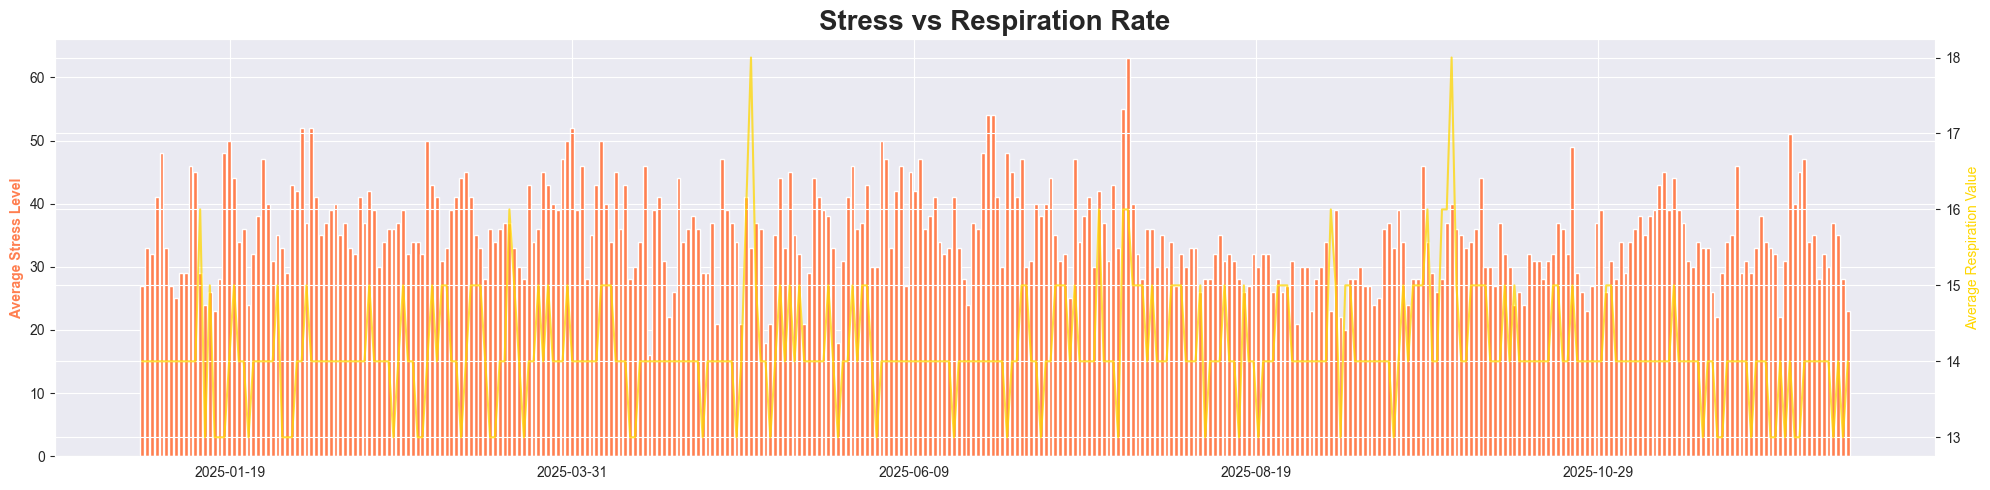

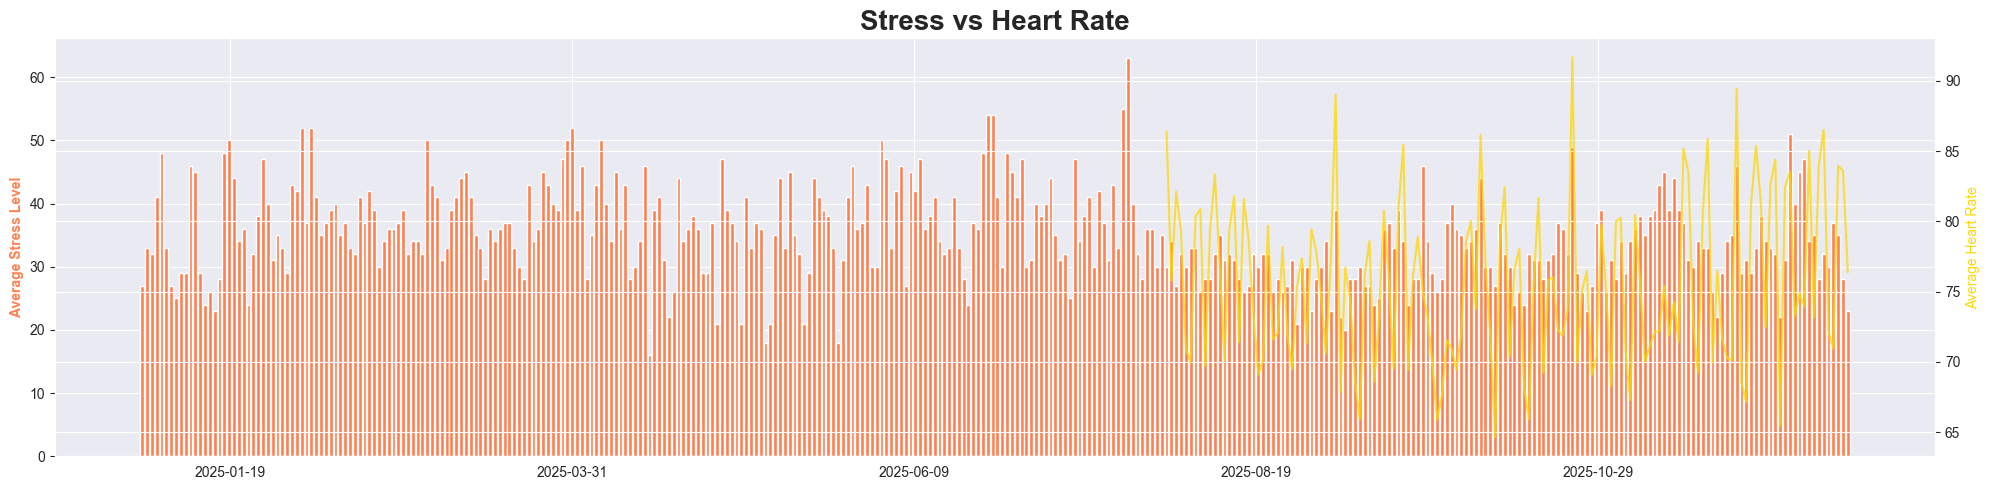

In [19]:
fix, ax1 = plt.subplots(figsize=[20,5])

ax1.bar(df_viz['Date'], df_viz['Average Stress Level'], color=MAIN_COLOR)
ax1.set_ylabel('Average Stress Level', fontweight='bold', color=MAIN_COLOR)

ax2 = ax1.twinx()

ax2.plot(df_viz['Date'], df_viz['Avg Waking Respiration Value'], color=REF_COLOR, alpha=.75)
ax2.set_ylabel('Average Respiration Value', color=REF_COLOR)

plt.title('Stress vs Respiration Rate', **TITLE_KKWARGS)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))

plt.tight_layout()
plt.show()

fix, ax1 = plt.subplots(figsize=[20,5])

ax1.bar(df_viz['Date'], df_viz['Average Stress Level'], color=MAIN_COLOR)
ax1.set_ylabel('Average Stress Level', fontweight='bold', color=MAIN_COLOR)

ax2 = ax1.twinx()

ax2.plot(df_viz['Date'], df_viz['Average Heart Rate'], color=REF_COLOR, alpha=.75)
ax2.set_ylabel('Average Heart Rate', color=REF_COLOR)

plt.title('Stress vs Heart Rate', **TITLE_KKWARGS)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(DATE_STEP))

plt.tight_layout()
plt.show()

# How my Body Battery effects my Stress Levels
The lower my body battery at the beginning of hte day, the more likely I am to be more stresed

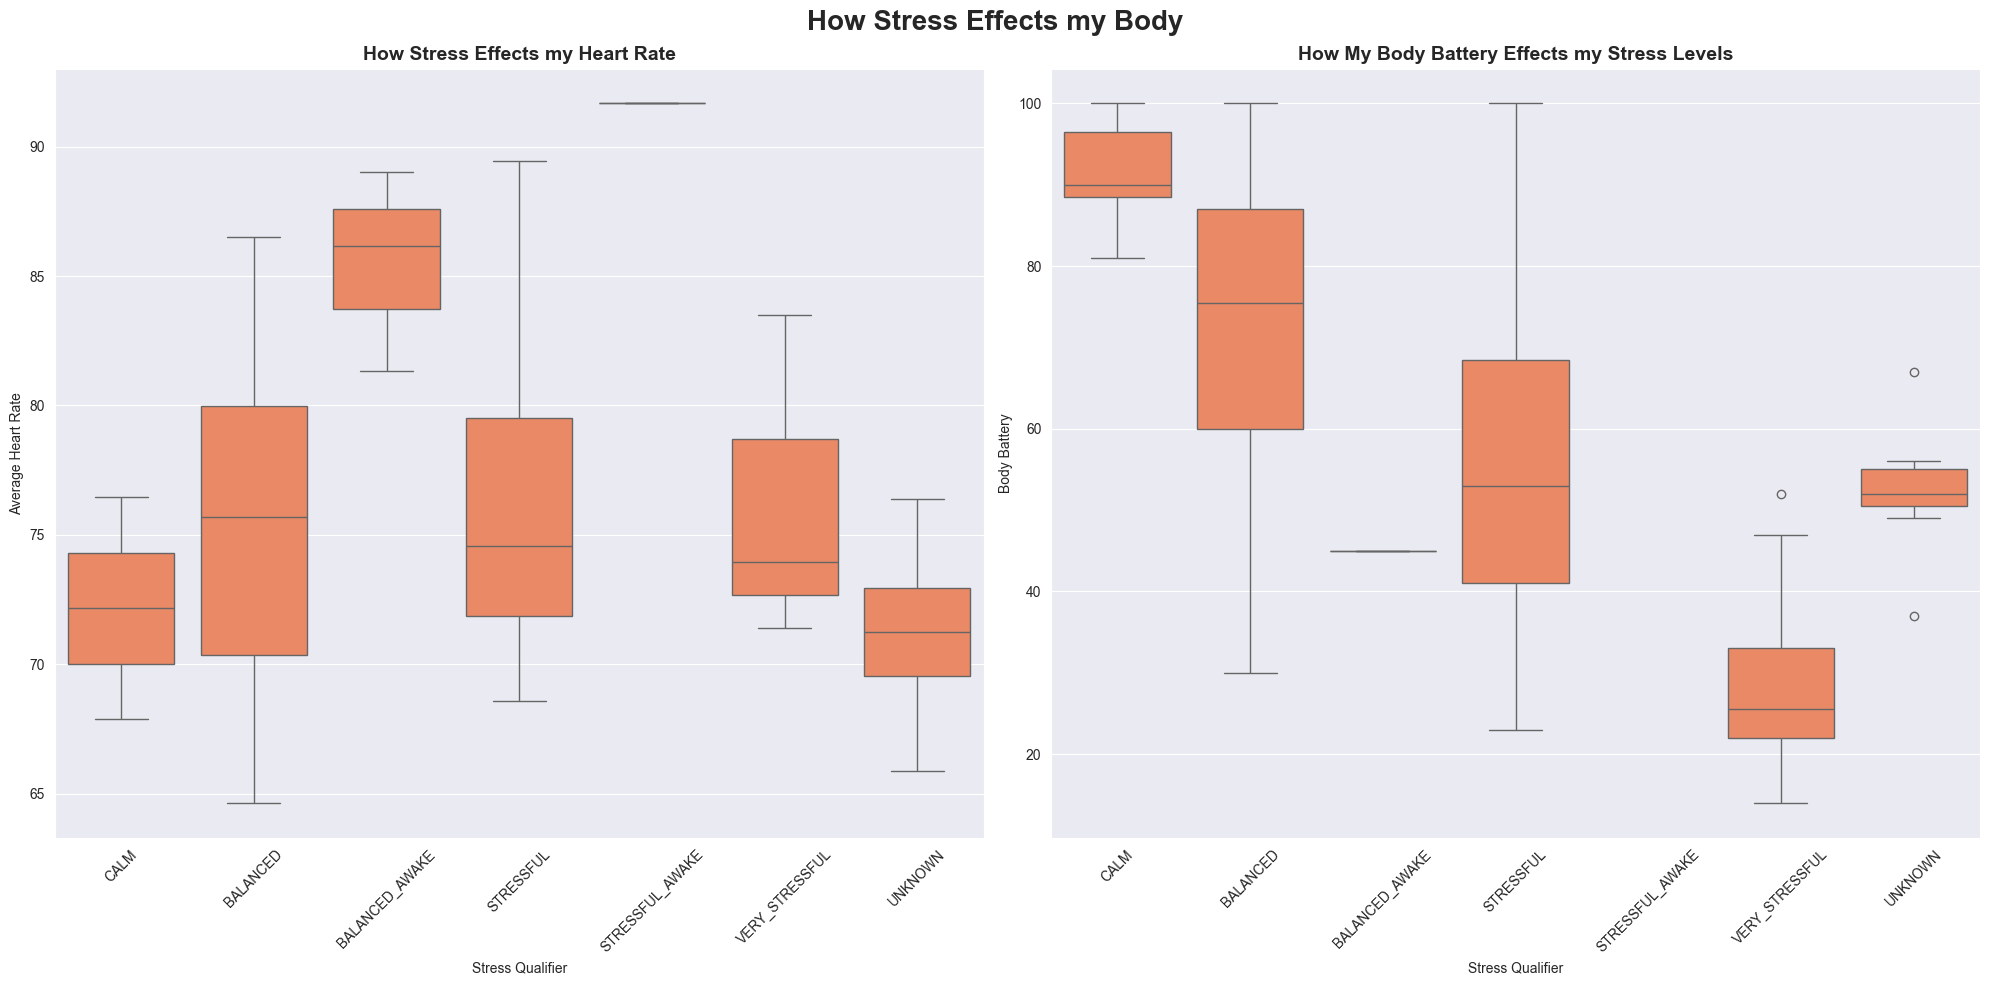

In [20]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
fig.suptitle('How Stress Effects my Body', **TITLE_KKWARGS)

sns.boxplot(df_viz,
            x='Stress Qualifier',
            y='Average Heart Rate',
            color=MAIN_COLOR,
            order=['CALM', 'BALANCED', 'BALANCED_AWAKE', 'STRESSFUL', 'STRESSFUL_AWAKE', 'VERY_STRESSFUL', 'UNKNOWN'], ax=ax1)
ax1.set_title('How Stress Effects my Heart Rate', **SUB_TITLE_KKWARGS)
ax1.tick_params(axis='x', rotation=45)


sns.boxplot(df_viz,
            x='Stress Qualifier',
            y='Body Battery',
            color=MAIN_COLOR,
            order=['CALM', 'BALANCED', 'BALANCED_AWAKE', 'STRESSFUL', 'STRESSFUL_AWAKE', 'VERY_STRESSFUL', 'UNKNOWN'], ax=ax2)
ax2.set_title('How My Body Battery Effects my Stress Levels', **SUB_TITLE_KKWARGS)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()